# New targets test: winsorized Delta-ratio


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 28.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna
from pathlib import Path as _P
import time as _time

SEED = 42
DATA_PATH = _P("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = 15
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
OPTUNA_TRIALS = 30
N_FINAL_SEEDS = 5
N_FOLDS_FV = 5
RATIO_WINSOR_Q = (0.005, 0.995)  # per-target quantile winsorization of the ratio level
DENOM = {"EBITDA": "Net_Sales", "Net_Income": "Net_Sales", "ROA": "Total_Assets"}
NUM = {"EBITDA": "EBITDA", "Net_Income": "Net_Income", "ROA": "Net_Income"}   # ROA = Net_Income/Total_Assets

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Data Processing

In [ ]:
from collections import defaultdict


def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    df = pd.read_csv(data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()

    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_input_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_input_cols))
    feature_cols = [col for col in df.columns
                    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    # Company targets size normalization
    recs = []
    for t in PREDICTION_TARGETS:
        num, den = NUM[t], DENOM[t]
        sub = year_end_records[year_end_records[t].notna()][["Company", "year", num, den]].copy()
        d = sub[den].astype(float)
        sub["ratio"] = np.where(d > 0, sub[num].astype(float) / d, np.nan)
        sub["target"] = t
        recs.append(sub[["Company", "year", "target", "ratio"]])
    panel = pd.concat(recs, ignore_index=True)

    # winsorize the ratio
    for t in PREDICTION_TARGETS:
        m = panel["target"] == t
        r = panel.loc[m, "ratio"].to_numpy(float)
        lo, hi = np.nanpercentile(r, [RATIO_WINSOR_Q[0] * 100, RATIO_WINSOR_Q[1] * 100])
        panel.loc[m, "ratio"] = np.clip(panel.loc[m, "ratio"], lo, hi)

    panel = panel.sort_values(["Company", "target", "year"]).reset_index(drop=True)
    panel_g = panel.groupby(["Company", "target"])
    panel["ratio_prev"] = panel_g["ratio"].shift(1)
    panel["d_ratio"] = panel["ratio"] - panel["ratio_prev"]          # target
    panel["d_ratio_prev"] = panel_g["d_ratio"].shift(1)

    label = defaultdict(dict)      # label[(company, year)][t] = d_ratio
    lag = defaultdict(dict)        # lag[(company, year)][t] = (ratio_prev, d_ratio_prev)
    for _, r in panel.iterrows():
        key = (r["Company"], int(r["year"]))
        if not np.isnan(r["d_ratio"]):
            label[key][r["target"]] = float(r["d_ratio"])
        if not np.isnan(r["ratio_prev"]) and not np.isnan(r["d_ratio_prev"]):
            lag[key][r["target"]] = (float(r["ratio_prev"]), float(r["d_ratio_prev"]))

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            key = (company, year)
            if key not in label or len(label[key]) < len(PREDICTION_TARGETS):
                continue
            if key not in lag or len(lag[key]) < len(PREDICTION_TARGETS):
                continue
            year_end_date = year_end_row["Date"]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[
                (company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)
            ].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            raw_window = window[feature_cols].to_numpy(dtype=np.float32)

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL"] + prior_static_cols
            mc_prior = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            lags = np.concatenate([
                np.array([lag[key][t][0], lag[key][t][1]], dtype=np.float32)
                for t in PREDICTION_TARGETS
            ])
            static_data = np.concatenate([mc_prior, lags])   # MC(3) + prior(9) + lags(6)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": raw_window,
                "static_data": static_data,
                "sector": sector_str,
                "window_dates": window["Date"].to_numpy(),
                "window_days": (window["Date"] - window["Date"].iloc[0]).dt.days.to_numpy(),
            })

    data_records = []
    for seq in sequences:
        key = (seq["company"], seq["year"])
        for target_name in PREDICTION_TARGETS:
            data_records.append({
                "company": seq["company"], "year": seq["year"],
                "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label[key][target_name],
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
                "window_dates": seq["window_dates"],
                "window_days": seq["window_days"],
            })

    return pd.DataFrame(data_records), feature_cols


data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)
print(f"Total rows: {len(data_df)}")
print(f"feature_cols ({len(feature_cols)}): {feature_cols}")

Total rows: 6114
feature_cols (34): ['Close', 'High', 'Low', 'Open', 'Volume', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'T5YIE', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_Mkt-RF', 'ff_HML', 'ff_Mom', 'Close_logret', 'Volume_log']


## Pipeline Setup: winsorized Delta-ratio targets, Sector + Prior + Lag Statics, 5-Fold TSCV

In [ ]:
def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty.")
    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years: {available_years}")
    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds.")
    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")
    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) is empty. Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")
    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

def fit_static_scaler(mtl_df, new_slice):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

SECTOR_LIST = sorted(data_df["sector"].dropna().unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)  # 12 dims (3 MC + 9 Prior_*)
    sector_oh = sector_onehot(sector_str)                          # N_SECTORS dims
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

# Drop samples whose prior-year fundamentals (or MC dummy) are NaN.
static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
n_drop_missing = int(static_nan_mask.sum())
data_df = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; {len(data_df)} remaining.")

data_df["static_data"] = data_df.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)
STATIC_DIM_IMP = 3 + N_SECTORS + 9 + 2 * len(PREDICTION_TARGETS)  # MC(3) + sector(N) + prior(9) + ratio lags(6)
NEW_STATIC_SLICE = slice(3 + N_SECTORS, STATIC_DIM_IMP)  # scale prior + lag block
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

def extract_mtl_df(df, new_slice=NEW_STATIC_SLICE):
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        row = group.iloc[0]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": row["year_end_date"],
            "window_data": row["window_data"],
            "static_data": row["static_data"],
            "window_dates": row["window_dates"],
            "window_days": row["window_days"],
            "label_value": label_value,
        })
    return pd.DataFrame(mtl_records)

# Target = Delta(winsorized size-normalized ratio); the per-target [0.5%, 99.5%]
# winsorization of the ratio level is done in the data-processing cell.
print(f"label (Delta ratio) stats: mean={data_df['label_value'].mean():.4f}, std={data_df['label_value'].std():.4f}")

# Build k-fold for HPO + single-split for final test
folds, test_data = temporal_kfold_split(data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
train_data, val_data, _ = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

mtl_train_data_raw = extract_mtl_df(train_data)
mtl_val_data_raw   = extract_mtl_df(val_data)
mtl_test_data      = extract_mtl_df(test_data)

train_per_year = mtl_train_data_raw["year"].value_counts().sort_index()
test_per_year  = mtl_test_data["year"].value_counts().sort_index()
print(f"Train: {len(mtl_train_data_raw)} ({dict(train_per_year)})")
print(f"Test:  {len(mtl_test_data)} ({dict(test_per_year)})")

Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 831 samples missing prior-year fundamentals; 5283 remaining.
STATIC_DIM_IMP=28 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:28 (only prior gets RobustScaler)
label (Delta ratio) stats: mean=0.0555, std=2.0099
Available years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (900 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (2370), val = 2019 (363)
  Fold 2: train <= 2019 (2733), val = 2020 (381)
  Fold 3: train <= 2020 (3114), val = 2021 (411)
  Fold 4: train <= 2021 (3525), val = 2022 (417)
  Fold 5: train <= 2022 (3942), val = 2023 (441)
Available years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (900 samples)


## Frequencies feature selection for MultiFreqLSTM

In [ ]:
DAILY_FEATURES = [
    'Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield',
    'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume',
    'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close',
    'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom',
    'TTF_Gas_Close', 'NFCI',
]
MONTHLY_FEATURES = ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
QUARTERLY_FEATURES = ['IT_GDP']

print(f"Daily ({len(DAILY_FEATURES)}): {DAILY_FEATURES}")
print(f"Monthly ({len(MONTHLY_FEATURES)}): {MONTHLY_FEATURES}")
print(f"Quarterly ({len(QUARTERLY_FEATURES)}): {QUARTERLY_FEATURES}")

daily_indices     = [feature_cols.index(f) for f in DAILY_FEATURES]
monthly_indices   = [feature_cols.index(f) for f in MONTHLY_FEATURES]
quarterly_indices = [feature_cols.index(f) for f in QUARTERLY_FEATURES]

Daily (21): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom', 'TTF_Gas_Close', 'NFCI']
Monthly (5): ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
Quarterly (1): ['IT_GDP']


## Model Definitions

In [ ]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_targets=3, dropout=0.2, static_dim=0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, num_targets=3,
                 dropout=0.2, static_dim=0):
        super().__init__()
        self.static_dim = static_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

class MultiFreqLSTM_NoQuarterly(nn.Module):
    """Two-stream variant of MultiFreqLSTM: daily + monthly only.
    Quarterly IT_GDP is folded into the monthly stream (forward-filled at
    monthly cadence), so no separate quarterly MLP is used."""
    def __init__(self, n_daily, n_monthly, n_static,
                 d_daily=64, d_monthly=32,
                 n_layers_daily=2, n_layers_monthly=1,
                 num_targets=3, dropout=0.1):
        super().__init__()
        self.daily = nn.LSTM(n_daily, d_daily, num_layers=n_layers_daily,
                            batch_first=True, dropout=0.0)
        self.monthly = nn.LSTM(n_monthly, d_monthly, num_layers=n_layers_monthly,
                              batch_first=True, dropout=0.0)
        self.merge_dim = d_daily + d_monthly + n_static
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.merge_dim, num_targets)
        self._squeeze = (num_targets == 1)

    def forward(self, daily, monthly, quarterly, lengths, static):
        packed_d = pack_padded_sequence(daily, lengths.cpu(),
                                        batch_first=True, enforce_sorted=True)
        _, (h_d, _) = self.daily(packed_d)
        h_d = h_d[-1]

        B = monthly.size(0)
        lengths_m = torch.full((B,), 12, dtype=torch.long, device=monthly.device)
        packed_m = pack_padded_sequence(monthly, lengths_m.cpu(),
                                        batch_first=True, enforce_sorted=False)
        _, (h_m, _) = self.monthly(packed_m)
        h_m = h_m[-1]

        h = torch.cat([h_d, h_m, static.to(h_d.device, h_d.dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits

class GroupedLSTM(nn.Module):
    """Model D: K parallel daily LSTM streams, one per group of temporally
    correlated features. Groups are found via hierarchical clustering of the
    Spearman correlation (computed on training data only). All streams share
    the same daily (252-step) cadence, so no sequence packing is needed."""
    def __init__(self, group_sizes, hidden_sizes, n_layers, n_static,
                 num_targets=3, dropout=0.1):
        super().__init__()
        self.n_groups = len(group_sizes)
        self.streams = nn.ModuleList([
            nn.LSTM(group_sizes[g], hidden_sizes[g], num_layers=n_layers[g],
                    batch_first=True, dropout=0.0)
            for g in range(self.n_groups)
        ])
        self.merge_dim = int(sum(hidden_sizes)) + n_static
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.merge_dim, num_targets)
        self._squeeze = (num_targets == 1)

    def forward(self, groups, static):
        hs = []
        for g in range(self.n_groups):
            _, (hn, _) = self.streams[g](groups[g])
            hs.append(hn[-1])
        h = torch.cat(hs + [static.to(hs[0].device, hs[0].dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits

selected_indices = [feature_cols.index(f) for f in (DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES)]

print("Models defined: ShallowLSTM, StackedLSTM, MultiFreqLSTM_NoQuarterly, GroupedLSTM")
def init_lstm_submodule(model, head_std=1e-3):
    """Weight init for Shallow/Stacked LSTM and MultiFreqLSTM_NoQuarterly.
    - Xavier-uniform on every LSTM weight.
    - LSTM biases: zero, except the forget-gate slice, which is set to 1.0
      (PyTorch default for stable LSTM training).
    - Small normal head (std=head_std) + zero bias so initial output ~ 0.
    """
    for m in model.modules():
        cls_name = type(m).__name__
        if cls_name == "LSTM":
            for name, p in m.named_parameters():
                if "weight" in name:
                    nn.init.xavier_uniform_(p)
                elif "bias" in name:
                    nn.init.zeros_(p)
                    n = p.numel() // 4
                    with torch.no_grad():
                        p[n:2*n].fill_(1.0)  # forget-gate bias = 1
    if hasattr(model, "head"):
        nn.init.normal_(model.head.weight, mean=0.0, std=head_std)
        nn.init.zeros_(model.head.bias)

GROUPED_K = 3
GROUPED_HIDDEN_SIZES = [64, 32, 32]
GROUPED_N_LAYERS = [2, 1, 1]


Models defined: ShallowLSTM, StackedLSTM, MultiFreqLSTM_NoQuarterly, GroupedLSTM


## Datasets & DataLoaders

In [ ]:
def aggregate_to_cadence(window_dates, window_days, raw_window, target_indices, n_steps):
    """Aggregate a raw window to `n_steps` evenly-spaced bins (by day of year).
    raw_window: (T, F) array; target_indices: list of feature column indices to keep.
    Returns (n_steps, len(target_indices)) array, with NaN if no observations.
    """
    T = raw_window.shape[0]
    if T < 2:
        return np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    last_day = float(window_days[-1])
    if last_day <= 0:
        return np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    bin_size = last_day / n_steps
    out = np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    if len(target_indices) == 0:
        return out
    # Assign each timestep to its bin
    bin_idx = np.minimum((window_days / bin_size).astype(int), n_steps - 1)
    for f_i, f_idx in enumerate(target_indices):
        col = raw_window[:, f_idx]
        for b in range(n_steps):
            mask = bin_idx == b
            if mask.any():
                vals = col[mask]
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    out[b, f_i] = vals[-1]  # take last non-NaN value (forward-fill)
    return out

def build_multifreq_window(raw_window, window_days, daily_idx, monthly_idx, quarterly_idx,
                            n_daily=252, n_monthly=12, n_quarterly=4):
    """Aggregate the raw window to the 3 cadences."""
    daily    = aggregate_to_cadence(None, window_days, raw_window, daily_idx,     n_daily)
    monthly  = aggregate_to_cadence(None, window_days, raw_window, monthly_idx,   n_monthly)
    quarterly = aggregate_to_cadence(None, window_days, raw_window, quarterly_idx, n_quarterly)
    # Forward-fill along the time axis (within stream)
    for arr in (daily, monthly, quarterly):
        for f in range(arr.shape[1]):
            last = np.nan
            for t in range(arr.shape[0]):
                if np.isnan(arr[t, f]):
                    arr[t, f] = last
                else:
                    last = arr[t, f]
            # Backward-fill leading NaNs
            if np.isnan(arr[0, f]):
                first_valid = np.nan
                for t in range(arr.shape[0]):
                    if not np.isnan(arr[t, f]):
                        first_valid = arr[t, f]
                        break
                arr[:, f] = first_valid
    # Replace any remaining NaN with 0
    daily    = np.nan_to_num(daily,    nan=0.0).astype(np.float32)
    monthly  = np.nan_to_num(monthly,  nan=0.0).astype(np.float32)
    quarterly = np.nan_to_num(quarterly, nan=0.0).astype(np.float32)
    return daily, monthly, quarterly

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler is not None:
            window = self.scaler.transform(window)
            # Sanitize: RobustScaler can produce NaN/Inf
            window = np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        static = row["static_data"].astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

class MultiFreqDataset(Dataset):
    def __init__(self, mtl_df, daily_scaler, monthly_scaler, quarterly_scaler, stat_scaler,
                 daily_idx, monthly_idx, quarterly_idx, n_daily=252, n_monthly=12, n_quarterly=4):
        self.mtl_df = mtl_df.reset_index(drop=True)
        self.daily_scaler = daily_scaler
        self.monthly_scaler = monthly_scaler
        self.quarterly_scaler = quarterly_scaler
        self.stat_scaler = stat_scaler
        self.daily_idx = daily_idx
        self.monthly_idx = monthly_idx
        self.quarterly_idx = quarterly_idx
        self.n_daily = n_daily
        self.n_monthly = n_monthly
        self.n_quarterly = n_quarterly

    def __len__(self):
        return len(self.mtl_df)

    def __getitem__(self, idx):
        row = self.mtl_df.iloc[idx]
        raw_window = row["window_data"]
        window_days = row["window_days"]
        d, m, q = build_multifreq_window(
            raw_window, window_days,
            self.daily_idx, self.monthly_idx, self.quarterly_idx,
            n_daily=self.n_daily, n_monthly=self.n_monthly, n_quarterly=self.n_quarterly,
        )
        if self.daily_scaler is not None:
            d = self.daily_scaler.transform(d)
            d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.monthly_scaler is not None:
            m = self.monthly_scaler.transform(m)
            m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.quarterly_scaler is not None:
            q = self.quarterly_scaler.transform(q)
            q = np.nan_to_num(q, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.stat_scaler is not None:
            static = self.stat_scaler.transform(
                row["static_data"].reshape(1, -1)
            ).reshape(-1).astype(np.float32)
        else:
            static = row["static_data"].astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(d.astype(np.float32)),
            torch.from_numpy(m.astype(np.float32)),
            torch.from_numpy(q.astype(np.float32)),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            self.n_daily,
        )

def collate_fn_multifreq(batch):
    batch.sort(key=lambda x: x[6], reverse=True)
    ds = torch.stack([x[0] for x in batch])
    ms = torch.stack([x[1] for x in batch])
    qs = torch.stack([x[2] for x in batch])
    statics = torch.stack([x[3] for x in batch])
    targets = torch.stack([x[4] for x in batch])
    masks = torch.stack([x[5] for x in batch])
    lengths = torch.tensor([x[6] for x in batch])
    return ds, ms, qs, targets, masks, statics, lengths


class GroupedDataset(Dataset):
    """Model D dataset: daily-aggregated window split into K correlated-feature
    groups. Returns K group tensors (all (n_daily, group_size)) + static/target/mask."""
    def __init__(self, mtl_df, group_idx_list, scaler, stat_scaler, n_daily=252):
        self.mtl_df = mtl_df.reset_index(drop=True)
        self.group_idx_list = [list(g) for g in group_idx_list]
        self.scaler = scaler
        self.stat_scaler = stat_scaler
        self.n_daily = n_daily
        self.all_idx = [idx for g in self.group_idx_list for idx in g]

    def __len__(self):
        return len(self.mtl_df)

    def __getitem__(self, idx):
        row = self.mtl_df.iloc[idx]
        d, _, _ = build_multifreq_window(
            row["window_data"], row["window_days"], self.all_idx, [], [],
        )
        if self.scaler is not None:
            d = self.scaler.transform(d)
            d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        groups = []
        col = 0
        for g in self.group_idx_list:
            groups.append(torch.from_numpy(d[:, col:col + len(g)]))
            col += len(g)
        static = row["static_data"].astype(np.float32)
        if self.stat_scaler is not None:
            static = self.stat_scaler.transform(
                static.reshape(1, -1)
            ).reshape(-1).astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            *groups,
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
        )


def collate_fn_grouped(batch):
    n_groups = len(batch[0]) - 3
    group_tensors = [torch.stack([x[g] for x in batch]) for g in range(n_groups)]
    statics = torch.stack([x[n_groups] for x in batch])
    targets = torch.stack([x[n_groups + 1] for x in batch])
    masks = torch.stack([x[n_groups + 2] for x in batch])
    return (*group_tensors, targets, masks, statics)


## Correlation feature grouping for GroupedLSTM (Model D)


In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

def compute_corr_groups(mtl_df, feature_indices, k=3):
    """Cluster `feature_indices` into `k` groups by Spearman correlation over time.

    Each training window is aggregated to a common daily (252-bin) grid and each
    feature is z-scored within its window (so we capture temporal co-movement, not
    level differences across companies). Hierarchical agglomerative clustering
    (average linkage) is run on the distance 1 - |corr|, so anti-correlated
    features are grouped together. Returns a list of `k` lists of column indices.
    """
    n_daily = 252
    pooled = []
    for _, row in mtl_df.iterrows():
        d, _, _ = build_multifreq_window(row["window_data"], row["window_days"],
                                         feature_indices, [], [], n_daily=n_daily)
        d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
        mu = d.mean(axis=0, keepdims=True)
        sd = d.std(axis=0, keepdims=True) + 1e-8
        pooled.append((d - mu) / sd)
    X = np.vstack(pooled)
    corr = pd.DataFrame(X).corr(method="spearman").to_numpy()
    corr = np.nan_to_num(corr, nan=0.0)
    dist = 1.0 - np.abs(corr)
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist), method="average")
    labels = fcluster(Z, t=k, criterion="maxclust")
    groups = []
    for c in sorted(set(labels)):
        groups.append([feature_indices[i] for i in range(len(feature_indices)) if labels[i] == c])
    return groups

def describe_corr_groups(groups):
    return [[feature_cols[i] for i in g] for g in groups]

_demo_mtl = extract_mtl_df(train_data)
_demo_groups = compute_corr_groups(_demo_mtl, selected_indices, k=3)
for _gi, _g in enumerate(describe_corr_groups(_demo_groups), start=1):
    print(f"Group {_gi} ({len(_g)}): {_g}")


Group 1 (24): ['Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'TTF_Gas_Close', 'NFCI', 'Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM', 'IT_GDP']
Group 2 (2): ['ff_HML', 'ff_Mom']
Group 3 (1): ['Close_logret']


## Training with Regularization setup

In [ ]:
def fwd_mtl(batch):
    """Shallow/Stacked LSTM batch -> (model_args, targets, mask), on DEVICE."""
    bx, by, bmask, bstatic, lengths = batch
    return ((bx.to(DEVICE), lengths, bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def fwd_mf(batch):
    """MultiFreqLSTM batch -> (model_args, targets, mask), on DEVICE."""
    bd, bm, bq, by, bmask, bstatic, lengths = batch
    return ((bd.to(DEVICE), bm.to(DEVICE), bq.to(DEVICE), lengths, bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def fwd_grouped(batch):
    """GroupedLSTM batch -> (model_args, targets, mask), on DEVICE."""
    *groups, by, bmask, bstatic = batch
    return (([g.to(DEVICE) for g in groups], bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def collect_predictions(model, loader, adapt):
    """Run model on loader; return (preds, targets, mask) numpy arrays."""
    model.eval()
    P, T, M = [], [], []
    with torch.no_grad():
        for batch in loader:
            args, by, bmask = adapt(batch)
            logits = model(*args)
            P.append(logits.cpu().numpy())
            T.append(by.cpu().numpy())
            M.append(bmask.cpu().numpy())
    if not P:
        return None
    return np.vstack(P), np.vstack(T), np.vstack(M).astype(bool)


def evaluate_loader(model, loader, adapt):
    """Per-target + Overall MAE (Delta-ratio space) on a loader."""
    out = collect_predictions(model, loader, adapt)
    if out is None:
        return None
    yp, yt, mask = out
    res = {}
    all_err = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        errs = np.abs(yp[m, i] - yt[m, i])
        res[t] = float(errs.mean())
        all_err.extend(errs.tolist())
    res["Overall"] = float(np.mean(all_err)) if all_err else None
    return res


def train_and_eval(model, train_loader, val_loader, optimizer, adapt,
                   trial=None, step_offset=0, collect_history=False):
    """Generic training loop shared by every architecture.
    Masked L1 loss, ReduceLROnPlateau (patience=5), early stopping (PATIENCE),
    grad clipping (max_norm=1.0) and best-state checkpointing on val MAE.
    `adapt(batch) -> (model_args, targets, mask)` handles the batch layout and
    the DEVICE transfers of each architecture.
    If collect_history, also returns per-epoch train loss (L1), val loss (L1)
    and val MAE histories plus the best (validation) epoch."""
    criterion = nn.L1Loss(reduction='none')
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    best_state = None
    best_metric = float("inf")
    epochs_no_improve = 0
    best_epoch = 0
    train_loss_history = []
    val_metric_history = []
    val_loss_history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_epoch = 0.0
        n_batches = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            args, by, bmask = adapt(batch)
            logits = model(*args)
            loss_m = criterion(logits, by)
            loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0 * loss_m.sum()
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                if not torch.isfinite(loss):
                    continue
                train_loss_epoch += loss.item()
                n_batches += 1
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        out = collect_predictions(model, val_loader, adapt)
        if out is None:
            break
        y_pred, y_true, mask = out
        valid_sum, count = 0.0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0:
                continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = valid_sum / max(1, count)
        scheduler.step(current_metric)
        val_metric_history.append(current_metric)
        val_loss_history.append(current_metric)  # same Delta-ratio L1 space as train loss
        train_loss_history.append(train_loss_epoch / max(1, n_batches))

        if np.isfinite(current_metric) and current_metric < best_metric:
            best_metric = current_metric
            best_state = {n: t.detach().cpu().clone() for n, t in model.state_dict().items()}
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if trial is not None:
            trial.report(current_metric, step_offset + epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        if epochs_no_improve >= PATIENCE:
            break

    history = {
        'epochs': list(range(1, len(val_metric_history) + 1)),
        'train_loss': train_loss_history,
        'val_metric': val_metric_history,
        'val_loss': val_loss_history,
        'best_epoch': best_epoch,
    }
    if best_state is not None:
        model.load_state_dict(best_state)
    if collect_history:
        return model, best_metric, best_epoch, history
    return model, best_metric, best_epoch


print("Training/eval helpers ready.")


Training/eval helpers ready.


## Loader builders per model

In [ ]:
def build_mtl_loaders_for_fold(tr_df, va_df, params, feature_indices, static_dim):
    """Build train/val/test loaders for MTL (Shallow or Stacked LSTM).
    Returns (model, train_loader, val_loader, test_loader, scaler, stat_scaler)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    temp_sc = make_robust_scaler(tr_mtl, feature_indices)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = YoYDatasetMTL(tr_mtl_s, temp_sc, feature_indices)
    va_ds = YoYDatasetMTL(va_mtl_s, temp_sc, feature_indices)
    te_ds = YoYDatasetMTL(te_mtl_s, temp_sc, feature_indices)
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_mtl)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    return tr_loader, va_loader, te_loader, temp_sc, stat_sc

def make_shallow_mtl(tr_df, va_df, params, feature_indices):
    tr_loader, va_loader, te_loader, _, _ = build_mtl_loaders_for_fold(
        tr_df, va_df, params, feature_indices, STATIC_DIM_IMP)
    model = ShallowLSTM(
        input_size=len(feature_indices),
        hidden_size=params['hidden_size'],
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader

def make_stacked_mtl(tr_df, va_df, params, feature_indices, num_layers=4):
    tr_loader, va_loader, te_loader, _, _ = build_mtl_loaders_for_fold(
        tr_df, va_df, params, feature_indices, STATIC_DIM_IMP)
    model = StackedLSTM(
        input_size=len(feature_indices),
        hidden_size=params['hidden_size'],
        num_layers=num_layers,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader

# Optuna Search

In [ ]:
def get_hpo_objective_mtl(make_model_fn, feature_indices, n_trials=OPTUNA_TRIALS):
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    temp_sc = make_robust_scaler(tr_mtl, feature_indices)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.5)
        params = dict(hidden_size=hidden_size, lr=lr, batch_size=batch_size,
                      weight_decay=weight_decay, dropout=dropout)
        tr_ds = YoYDatasetMTL(tr_mtl_s, temp_sc, feature_indices)
        va_ds = YoYDatasetMTL(va_mtl_s, temp_sc, feature_indices)
        tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn_mtl)
        va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_mtl)
        model = make_model_fn(params, feature_indices)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_mtl,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        return best_metric
    return objective

def run_optuna(study_name, objective_fn, n_trials=OPTUNA_TRIALS, seed_trials=None):
    pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=study_name, pruner=pruner)
    for t in (seed_trials or []):
        study.enqueue_trial(t)
    study.optimize(objective_fn, n_trials=n_trials)
    return study

## Model A: ShallowLSTM

In [ ]:
selected_indices = [feature_cols.index(f) for f in (DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES)]
print(f"Using {len(selected_indices)} features for Shallow/Stacked LSTM input.")

def make_shallow_fn(params, fi):
    model = ShallowLSTM(len(selected_indices), params['hidden_size'], len(PREDICTION_TARGETS),
                        params.get('dropout', 0.2), static_dim=STATIC_DIM_IMP).to(DEVICE)
    init_lstm_submodule(model)
    return model

_t0 = _time.time()
study_A = run_optuna(
    "shallow_reg",
    get_hpo_objective_mtl(make_shallow_fn, selected_indices),
    n_trials=OPTUNA_TRIALS,
    seed_trials=[{
        'hidden_size': 128, 'lr': 0.00859001743156823, 'batch_size': 16,
        'weight_decay': 7.262266887516058e-05, 'dropout': 0.05642680822122102,
    }],
)
print(f"\nShallowLSTM best val MAE: {study_A.best_value:.4f}")
print(f"Best params: {study_A.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")

Using 27 features for Shallow/Stacked LSTM input.


[I 2026-08-22 22:32:08,744] A new study created in memory with name: shallow_reg
[I 2026-08-22 22:33:43,072] Trial 0 finished with value: 0.19296525418758392 and parameters: {'hidden_size': 128, 'lr': 0.00859001743156823, 'batch_size': 16, 'weight_decay': 7.262266887516058e-05, 'dropout': 0.05642680822122102}. Best is trial 0 with value: 0.19296525418758392.
[I 2026-08-22 22:34:25,914] Trial 1 finished with value: 0.2053360939025879 and parameters: {'hidden_size': 32, 'lr': 0.0015406844740086575, 'batch_size': 64, 'weight_decay': 0.0002932009944034385, 'dropout': 0.3613808557911829}. Best is trial 0 with value: 0.19296525418758392.
[I 2026-08-22 22:36:52,042] Trial 2 finished with value: 0.20941932499408722 and parameters: {'hidden_size': 32, 'lr': 0.0001402144278972328, 'batch_size': 32, 'weight_decay': 2.4079940452144706e-05, 'dropout': 0.4591008361115165}. Best is trial 0 with value: 0.19296525418758392.
[I 2026-08-22 22:38:32,262] Trial 3 finished with value: 0.21983738243579865 an


ShallowLSTM best val MAE: 0.1828
Best params: {'hidden_size': 128, 'lr': 0.009258075025171411, 'batch_size': 16, 'weight_decay': 0.00012878865067519215, 'dropout': 0.06837538688873493}
Optuna time: 28.1 min


## Model B: StackedLSTM (L=4)

In [ ]:
def make_stacked_fn(params, fi, num_layers=4):
    model = StackedLSTM(
        input_size=len(selected_indices),
        hidden_size=params['hidden_size'],
        num_layers=num_layers,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model

_t0 = _time.time()
study_B = run_optuna(
    "stacked4_reg",
    get_hpo_objective_mtl(make_stacked_fn, selected_indices),
    n_trials=OPTUNA_TRIALS,
    seed_trials=[{
        'hidden_size': 128, 'lr': 0.00859001743156823, 'batch_size': 16,
        'weight_decay': 7.262266887516058e-05, 'dropout': 0.05642680822122102,
    }],
)
print(f"\nStackedLSTM L=4 best val MAE: {study_B.best_value:.4f}")
print(f"Best params: {study_B.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")

[I 2026-08-22 23:00:13,685] A new study created in memory with name: stacked4_reg
[I 2026-08-22 23:04:17,563] Trial 0 finished with value: 0.2038518190383911 and parameters: {'hidden_size': 128, 'lr': 0.00859001743156823, 'batch_size': 16, 'weight_decay': 7.262266887516058e-05, 'dropout': 0.05642680822122102}. Best is trial 0 with value: 0.2038518190383911.
[I 2026-08-22 23:05:29,342] Trial 1 finished with value: 0.20151185989379883 and parameters: {'hidden_size': 128, 'lr': 0.0010883624055861827, 'batch_size': 64, 'weight_decay': 3.251851940746887e-05, 'dropout': 0.04668341764028083}. Best is trial 1 with value: 0.20151185989379883.
[I 2026-08-22 23:07:14,642] Trial 2 finished with value: 0.19702942669391632 and parameters: {'hidden_size': 32, 'lr': 0.0011538601125640716, 'batch_size': 32, 'weight_decay': 2.6909895912273375e-06, 'dropout': 0.48962267792752256}. Best is trial 2 with value: 0.19702942669391632.
[I 2026-08-22 23:08:25,571] Trial 3 finished with value: 0.20414532721042633


StackedLSTM L=4 best val MAE: 0.1846
Best params: {'hidden_size': 32, 'lr': 0.004720627112368398, 'batch_size': 32, 'weight_decay': 7.440091682715945e-05, 'dropout': 0.19676616504955433}
Optuna time: 36.2 min


## Model C: MultiFreqLSTM (Daily and Monthly only)


In [ ]:
OPTUNA_TRIALS = 8

def make_mf_c_fn_for_optuna(params):
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_indices) + len(quarterly_indices),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model

def get_hpo_objective_mf_gdp():
    """IT_GDP is folded into the monthly stream"""
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    monthly_gdp_idx = monthly_indices + quarterly_indices
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        params = dict(
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            dropout=trial.suggest_float("dropout", 0.1, 0.5),
            n_layers_daily=2,
            n_layers_monthly=1,
        )
        tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
        model = make_mf_c_fn_for_optuna(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_mf,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed: {type(e).__name__}: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float('inf')
        return best_metric
    return objective

_t0 = _time.time()
study_C = run_optuna(
    "multifreq_c_reg",
    get_hpo_objective_mf_gdp(),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nMultiFreqLSTM best val MAE: {study_C.best_value:.4f}")
print(f"Best params: {study_C.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")

[I 2026-08-22 23:36:27,899] A new study created in memory with name: multifreq_c_reg
[I 2026-08-23 00:03:52,490] Trial 0 finished with value: 0.21362240612506866 and parameters: {'batch_size': 32, 'lr': 0.003426541759056412, 'weight_decay': 1.069527919185214e-05, 'dropout': 0.13400855244002063}. Best is trial 0 with value: 0.21362240612506866.
[I 2026-08-23 00:56:40,898] Trial 1 finished with value: 0.2378569394350052 and parameters: {'batch_size': 64, 'lr': 0.00012678444391848214, 'weight_decay': 5.8441731061281565e-06, 'dropout': 0.36012713866882784}. Best is trial 0 with value: 0.21362240612506866.
[I 2026-08-23 01:39:23,588] Trial 2 finished with value: 0.233956977725029 and parameters: {'batch_size': 16, 'lr': 0.00016339842346067384, 'weight_decay': 0.0005985666851868606, 'dropout': 0.394122508364697}. Best is trial 0 with value: 0.21362240612506866.
[I 2026-08-23 02:22:46,453] Trial 3 finished with value: 0.22220636904239655 and parameters: {'batch_size': 16, 'lr': 0.001179857516

## Model D: GroupedLSTM (correlation-grouped, daily cadence)


In [ ]:
def make_grouped_d_fn_for_optuna(params, group_sizes):
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model

def get_hpo_objective_grouped():
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        params = dict(
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            dropout=trial.suggest_float("dropout", 0.1, 0.5),
            hidden_sizes=GROUPED_HIDDEN_SIZES,
            n_layers=GROUPED_N_LAYERS,
        )
        tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
        va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_grouped)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_grouped)
        model = make_grouped_d_fn_for_optuna(params, group_sizes)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_grouped,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed: {type(e).__name__}: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float('inf')
        return best_metric
    return objective

_t0 = _time.time()
study_D = run_optuna(
    "grouped_d_reg",
    get_hpo_objective_grouped(),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nGroupedLSTM best val MAE: {study_D.best_value:.4f}")
print(f"Best params: {study_D.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")


[I 2026-08-23 00:20:59,215] A new study created in memory with name: grouped_d_reg
[I 2026-08-23 00:58:31,768] Trial 0 finished with value: 0.21260857582092285 and parameters: {'batch_size': 16, 'lr': 0.003445904647534259, 'weight_decay': 1.7318805427835417e-06, 'dropout': 0.2015395696492234}. Best is trial 0 with value: 0.21260857582092285.
[I 2026-08-23 01:17:46,166] Trial 1 finished with value: 0.23254048824310303 and parameters: {'batch_size': 16, 'lr': 0.0012822996232538277, 'weight_decay': 0.0006076973803297602, 'dropout': 0.40416700304861874}. Best is trial 0 with value: 0.21260857582092285.
[I 2026-08-23 01:43:08,201] Trial 2 finished with value: 0.22440825402736664 and parameters: {'batch_size': 16, 'lr': 0.0010471229566820014, 'weight_decay': 9.349791356959554e-06, 'dropout': 0.1733595406283726}. Best is trial 0 with value: 0.21260857582092285.
[I 2026-08-23 02:15:56,357] Trial 3 finished with value: 0.21936076879501343 and parameters: {'batch_size': 64, 'lr': 0.0035631846009

# Evaluations

## Seeds run on test (2024+2025) for each model

In [ ]:
def run_n_seeded_final(make_model_fn, params, adapt, n_seeds=N_FINAL_SEEDS):
    """Train `n_seeds` independent models on the single split (train<=2022,
    val=2023) and evaluate each on test (2024+2025).
    `make_model_fn(params) -> (model, tr_loader, va_loader, te_loader)`.
    Returns (results, test_res_per_seed, preds_per_seed, hist_per_seed, raw_results)."""
    results = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
    raw_results = {t: {"nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
    hist_per_seed = []
    test_res_per_seed = []
    preds_per_seed = []
    for s in range(n_seeds):
        np.random.seed(SEED + s)
        torch.manual_seed(SEED + s)
        model, tr_loader, va_loader, te_loader = make_model_fn(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        model, _, _, history = train_and_eval(
            model, tr_loader, va_loader, optimizer, adapt, collect_history=True)
        test_res = evaluate_loader(model, te_loader, adapt)
        for k, v in test_res.items():
            results[k].append(v)
        test_res_per_seed.append(test_res)
        preds_per_seed.append(collect_predictions(model, te_loader, adapt))
        yp_aligned = collect_predictions_aligned(model, te_loader, adapt)
        raw_mae = raw_mae_delta_ratio(yp_aligned, test_meta)
        for k, v in raw_mae.items():
            raw_results[k]["nmae_pct"].append(v["nmae_pct"])
            raw_results[k]["r2"].append(v["r2"])
        hist_per_seed.append(history)
    return results, test_res_per_seed, preds_per_seed, hist_per_seed, raw_results


print("Multi-seed helper ready.")


Multi-seed helper ready.


In [ ]:
# Delta-ratio targets, predictions are mapped back to raw units:
#   predicted ratio_t  = ratio_prev + Delta_ratio_pred
#   predicted EBITDA_t = predicted ratio * Net_Sales_t
#   predicted NI_t     = predicted ratio * Net_Sales_t
#   predicted ROA_t    = predicted ratio

def build_test_meta():
    """Join mtl_test_data rows with raw annual fundamentals from the CSV.
    Returns a DataFrame aligned 1:1 with mtl_test_data (same row order)."""
    raw = pd.read_csv(DATA_PATH)
    raw["Date"] = pd.to_datetime(raw["Date"])
    raw["year"] = raw["Date"].dt.year
    ann = raw[raw[PREDICTION_TARGETS].notna().any(axis=1)].copy()
    ann = ann.sort_values(["Company", "Date"]).drop_duplicates(["Company", "year"], keep="last")
    ann = ann.set_index(["Company", "year"])

    meta = mtl_test_data[["company", "year"]].copy()
    keys = pd.MultiIndex.from_arrays([meta["company"], meta["year"]])
    prev_keys = pd.MultiIndex.from_arrays([meta["company"], meta["year"] - 1])

    cur_cols = ["EBITDA", "Net_Income", "ROA", "Net_Sales", "Total_Assets"]
    pri_cols = ["EBITDA", "Net_Income", "ROA"]
    cur = ann[cur_cols].reindex(keys).to_numpy(dtype=float)
    prior = ann[pri_cols].reindex(prev_keys).to_numpy(dtype=float)
    for j, c in enumerate(cur_cols):
        meta[c.lower() + "_cur"] = cur[:, j]
    for j, c in enumerate(pri_cols):
        meta["prior_" + c.lower()] = prior[:, j]

    # winsorized previous-year ratio (per target) from the unscaled static lags block
    static = np.vstack(mtl_test_data["static_data"].to_numpy())
    ratio_start = 3 + N_SECTORS + 9
    meta["ratio_prev"] = list(static[:, ratio_start::2])   # (N, 3) = [EBITDA, NI, ROA]
    return meta

test_meta = build_test_meta()
print(f"test_meta: {len(test_meta)} rows (aligned with mtl_test_data)")

def collect_predictions_aligned(model, loader, adapt):
    """Run the model on the test dataset one sample at a time and return
    predictions aligned 1:1 with the dataset (and therefore mtl_test_data)
    rows. Iterating the dataset directly avoids the length-sorted batch
    order produced by the collate functions."""
    model.eval()
    ds = loader.dataset
    P = []
    with torch.no_grad():
        for i in range(len(ds)):
            item = ds[i]
            if adapt is fwd_mtl:
                window, static, _, _, ln = item
                logits = model(window.unsqueeze(0).to(DEVICE),
                               torch.tensor([ln]), static.unsqueeze(0).to(DEVICE))
            elif adapt is fwd_mf:
                d, m, q, static, _, _, n_daily = item
                logits = model(d.unsqueeze(0).to(DEVICE), m.unsqueeze(0).to(DEVICE),
                               q.unsqueeze(0).to(DEVICE),
                               torch.tensor([n_daily]), static.unsqueeze(0).to(DEVICE))
            else:  # fwd_grouped
                *groups, static, _, _ = item
                gs = [g.unsqueeze(0).to(DEVICE) for g in groups]
                logits = model(gs, static.unsqueeze(0).to(DEVICE))
            P.append(logits.cpu().numpy())
    return np.concatenate(P, axis=0)

def raw_mae_delta_ratio(yp, meta):
    """Map delta-ratio predictions back to raw EBITDA / Net_Income / ROA and
    compute, per target, the scale-free metrics nMAE% (MAE / mean|actual|)
    and R2 (coefficient of determination) so models/notebooks are comparable."""
    ratio_prev = np.vstack(meta["ratio_prev"].to_numpy()).astype(float)  # (N, 3)
    net_sales = meta["net_sales_cur"].to_numpy(float)
    raw_pred = np.stack([
        (ratio_prev[:, 0] + yp[:, 0]) * net_sales,
        (ratio_prev[:, 1] + yp[:, 1]) * net_sales,
        ratio_prev[:, 2] + yp[:, 2],
    ], axis=1)
    truth = np.stack([meta["ebitda_cur"], meta["net_income_cur"], meta["roa_cur"]],
                     axis=1).astype(float)
    valid = (np.isfinite(raw_pred) & np.isfinite(truth)
             & (net_sales[:, None] > 0) & np.isfinite(ratio_prev))
    res = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = valid[:, i]
        if not m.any():
            res[t] = {"nmae_pct": float("nan"), "r2": float("nan")}
            continue
        p, a = raw_pred[m, i], truth[m, i]
        mae = float(np.mean(np.abs(p - a)))
        nmae_pct = 100.0 * mae / float(np.mean(np.abs(a)))
        ss_res = float(np.sum((p - a) ** 2))
        ss_tot = float(np.sum((a - a.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        res[t] = {"nmae_pct": nmae_pct, "r2": r2}
    return res


def print_raw_mae(raw_results, label):
    """Print per-target scale-free raw-scale metrics (nMAE% and R2)."""
    print(f"  Raw-scale test MAE {label}:")
    for k in PREDICTION_TARGETS:
        nm = np.mean(raw_results[k]["nmae_pct"]); nm_s = np.std(raw_results[k]["nmae_pct"])
        r2 = np.mean(raw_results[k]["r2"]); r2_s = np.std(raw_results[k]["r2"])
        print(f"    {k:11s}: nMAE {nm:.1f}% \u00b1 {nm_s:.1f}% | R\u00b2 {r2:.3f} \u00b1 {r2_s:.3f}")


def print_fold_raw(raw_dict, label):
    """Print per-target nMAE% and R2 for one fold's raw metrics (means over seeds)."""
    nmae_parts, r2_parts = [], []
    for t in PREDICTION_TARGETS:
        nmae_parts.append(f"{t} {np.mean(raw_dict[t]['nmae_pct']):.1f}%")
        r2_parts.append(f"{t} {np.mean(raw_dict[t]['r2']):.2f}")
    print(f"    {label:10s}: nMAE% {' | '.join(nmae_parts)}")
    print(f"    {'':10s}  R2   {' | '.join(r2_parts)}")


def print_cross_fold_raw(fold_raws, label):
    """Print per-target nMAE%/R2 (mean over seeds per fold, then mean ± std across folds)
    plus an average-over-targets line used to fill the comparison table."""
    by_t = {t: {"nms": [], "r2s": []} for t in PREDICTION_TARGETS}
    for fr in fold_raws:
        for t in PREDICTION_TARGETS:
            by_t[t]["nms"].append(float(np.mean(fr[t]["nmae_pct"])))
            by_t[t]["r2s"].append(float(np.mean(fr[t]["r2"])))
    nmae_parts, r2_parts = [], []
    for t in PREDICTION_TARGETS:
        nms = by_t[t]["nms"]; r2s = by_t[t]["r2s"]
        nmae_parts.append(f"{t} {np.mean(nms):.1f}%±{np.std(nms):.1f}")
        r2_parts.append(f"{t} {np.mean(r2s):.2f}±{np.std(r2s):.2f}")
    print(f"  {label:10s}: nMAE% {' | '.join(nmae_parts)}")
    print(f"  {'':10s}  R2   {' | '.join(r2_parts)}")
    avg_n = [float(np.mean([by_t[t]['nms'][i] for t in PREDICTION_TARGETS])) for i in range(len(fold_raws))]
    avg_r = [float(np.mean([by_t[t]['r2s'][i] for t in PREDICTION_TARGETS])) for i in range(len(fold_raws))]
    print(f"  {'':10s}  avg  nMAE% {np.mean(avg_n):.1f}±{np.std(avg_n):.1f} | R2 {np.mean(avg_r):.2f}±{np.std(avg_r):.2f}")


print("Raw-scale evaluation helpers ready.")


test_meta: 300 rows (aligned with mtl_test_data)
Raw-scale evaluation helpers ready.


In [ ]:
import seaborn as sns
PRED_COLOR = '#d35400'
TARGET_COLOR = '#2c3e50'


def _ratio_bins(data):
    lo, hi = np.percentile(data, [1, 99])
    bw = max((hi - lo) * 0.04, 1e-4)
    return np.arange(lo, hi + bw, bw)

def _ensemble_preds(preds_per_seed):
    """Mean test predictions (Delta-ratio space) across seeds.
    Test loaders use shuffle=False with deterministic length-sorted collation,
    so rows are aligned across seeds; targets/mask are identical -> take seed 0."""
    yp_mean = np.mean(np.stack([p[0] for p in preds_per_seed], axis=0), axis=0)
    _, yt, mask = preds_per_seed[0]
    return yp_mean, yt, mask

def _style_pred_axis(ax, data, title):
    p_lo, p_hi = np.percentile(data, [2.5, 97.5])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(p_lo, p_hi)
    ax.set_xlabel("Delta ratio", fontsize=10)
    ax.text(
        0.98, 0.95,
        f"95% in [{p_lo:.3f}, {p_hi:.3f}]\nmax [{data.min():.3f}, {data.max():.3f}]",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#bdc3c7', alpha=0.85),
    )
    ax.axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)

def _plot_prediction_distributions(yp, mask, model_name, tag):
    """1x3 grid: prediction distributions, Delta-ratio space."""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, len(PREDICTION_TARGETS), figsize=(18, 4.0), sharey='all')
        for i, target in enumerate(PREDICTION_TARGETS):
            ax = axes[i]
            data = yp[mask[:, i], i]
            data = data[np.isfinite(data)]
            bins = _ratio_bins(data)
            sns.histplot(data, bins=bins, kde=False, ax=ax, color=PRED_COLOR, alpha=0.75)
            _style_pred_axis(ax, data, f"{model_name} - {target}\n{tag}")
            if i == 0:
                ax.set_ylabel('Count')
            else:
                ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

def plot_prediction_distributions(preds_per_seed, model_name):
    """1x3 grid: ensemble (mean-over-seeds) test prediction distributions, Delta-ratio space."""
    yp, _, mask = _ensemble_preds(preds_per_seed)
    _plot_prediction_distributions(yp, mask, model_name, f"(mean of {len(preds_per_seed)} seeds)")

def _plot_predictions_vs_targets(yp, yt, mask, model_name, tag):
    """1x3 grid: real test targets (filled bars) vs predictions (step), Delta-ratio space."""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, len(PREDICTION_TARGETS), figsize=(18, 4.0), sharey='all')
        for i, target in enumerate(PREDICTION_TARGETS):
            ax = axes[i]
            m = mask[:, i]
            real = yt[m, i]
            real = real[np.isfinite(real)]
            pred = yp[m, i]
            pred = pred[np.isfinite(pred)]
            bins = _ratio_bins(np.concatenate([real, pred]))
            sns.histplot(real, bins=bins, kde=False, ax=ax, color=TARGET_COLOR, alpha=0.55,
                         label='Real targets (test)')
            sns.histplot(pred, bins=bins, kde=False, ax=ax, color=PRED_COLOR,
                         element='step', fill=False, linewidth=2.0,
                         label=f'{model_name} preds ({tag})')
            _style_pred_axis(ax, real, f"{model_name} vs real - {target}")
            ax.legend(fontsize=9, loc='upper left')
            if i == 0:
                ax.set_ylabel('Count')
            else:
                ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

def plot_predictions_vs_targets(preds_per_seed, model_name):
    """1x3 grid: real test targets (filled bars) vs ensemble predictions (step), Delta-ratio space."""
    yp, yt, mask = _ensemble_preds(preds_per_seed)
    _plot_predictions_vs_targets(yp, yt, mask, model_name, f"mean of {len(preds_per_seed)} seeds")

def _aggregate_fold_preds(per_fold, key='preds_trained'):
    """Mean Delta-ratio predictions over seeds per fold, then concatenate all folds."""
    yps, yts, masks = [], [], []
    for fold_idx in sorted(per_fold):
        pf = per_fold[fold_idx]
        preds = [pf[key][s] for s in sorted(pf[key])]
        yps.append(np.mean(np.stack(preds, axis=0), axis=0))
        yts.append(pf['targets'])
        masks.append(pf['masks'])
    return (np.concatenate(yps, axis=0), np.concatenate(yts, axis=0),
            np.concatenate(masks, axis=0).astype(bool))

def plot_prediction_distributions_agg(per_fold, model_name):
    n_seeds = len(next(iter(per_fold.values()))['preds_trained'])
    yp, _, mask = _aggregate_fold_preds(per_fold)
    _plot_prediction_distributions(yp, mask, model_name,
                                   f"({len(per_fold)} folds, mean of {n_seeds} seeds)")

def plot_predictions_vs_targets_agg(per_fold, model_name):
    n_seeds = len(next(iter(per_fold.values()))['preds_trained'])
    yp, yt, mask = _aggregate_fold_preds(per_fold)
    _plot_predictions_vs_targets(yp, yt, mask, model_name,
                                 f"all {len(per_fold)} folds, mean of {n_seeds} seeds")

def plot_training_curves(histories, model_name, tag=None):
    """1x2 grid: left = train loss vs val loss overlaid (Delta-ratio L1),
    right = val MAE (Delta-ratio). Red dashed vertical line marks the mean
    best validation epoch."""
    max_ep = max(len(h['val_metric']) for h in histories)
    ep = np.arange(1, max_ep + 1)
    tr = np.full((len(histories), max_ep), np.nan)
    va_l1 = np.full((len(histories), max_ep), np.nan)
    va_real = np.full((len(histories), max_ep), np.nan)
    for i, h in enumerate(histories):
        tr[i, :len(h['train_loss'])] = h['train_loss']
        va_l1[i, :len(h['val_loss'])] = h['val_loss']
        va_real[i, :len(h['val_metric'])] = h['val_metric']
    best_epoch_mean = float(np.mean([h['best_epoch'] for h in histories]))
    title_tag = f" ({tag})" if tag else ""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
        def _draw(ax, data, color, label):
            mean = np.nanmean(data, axis=0)
            std = np.nanstd(data, axis=0)
            ax.plot(ep, mean, color=color, linewidth=1.8, label=label)
            ax.fill_between(ep, mean - std, mean + std, color=color, alpha=0.18)
        _draw(axes[0], tr, '#2e86c1', 'Train loss (Delta-ratio L1)')
        _draw(axes[0], va_l1, '#e67e22', 'Val loss (Delta-ratio L1)')
        _draw(axes[1], va_real, '#8e44ad', 'Val MAE (Delta-ratio)')
        for ax in axes:
            ax.set_xlabel('Epoch')
            ax.set_xlim(1, max_ep)
            ax.axvline(best_epoch_mean, color='red', linestyle='--', linewidth=1.5,
                       label=f'best val epoch ~ {best_epoch_mean:.0f}')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
        axes[0].set_ylabel('Loss (Delta-ratio)')
        axes[1].set_ylabel('MAE (Delta-ratio)')
        fig.suptitle(f"{model_name} - training curves{title_tag} (n={len(histories)}, mean +/- 1sd)")
        plt.tight_layout()
        plt.show()

def plot_training_curves_agg(per_fold, model_name):
    histories = [h for pf in per_fold.values() for h in pf['histories'].values()]
    n_seeds = len(next(iter(per_fold.values()))['histories'])
    plot_training_curves(histories, model_name,
                         tag=f"{len(per_fold)} folds, mean of {n_seeds} seeds")


print("Prediction-distribution plot helpers ready.")

Prediction-distribution plot helpers ready.


In [ ]:
class _OptunaStudyStub:
    def __init__(self, best_value, best_params):
        self.best_value = float(best_value)
        self.best_trial = type('TrialStub', (), {'params': dict(best_params)})()

_OPTUNA_RESULTS_A = {
    'best_value': 0.18284179270267487,
    'best_params': {
        'hidden_size': 128, 'lr': 0.009258075025171411, 'batch_size': 16,
        'weight_decay': 0.00012878865067519215, 'dropout': 0.06837538688873493,
    },
}
_OPTUNA_RESULTS_B = {
    'best_value': 0.18459033966064453,
    'best_params': {
        'hidden_size': 32, 'lr': 0.004720627112368398, 'batch_size': 32,
        'weight_decay': 7.440091682715945e-05, 'dropout': 0.19676616504955433,
    },
}
_OPTUNA_RESULTS_C = {
    'best_value': 0.21362240612506866,
    'best_params': {
        'batch_size': 32, 'lr': 0.003426541759056412,
        'weight_decay': 1.069527919185214e-05, 'dropout': 0.13400855244002063,
        'n_layers_daily': 2, 'n_layers_monthly': 1,
    },
}

_OPTUNA_RESULTS_D = {
    'best_value': 0.19444449245929718,
    'best_params': {
        'batch_size': 32, 'lr': 0.005031423353614856, 'weight_decay': 0.0009883273916572637, 'dropout': 0.26065240793146327,
        'hidden_sizes': [64, 32, 32], 'n_layers': [2, 1, 1],
    },
}


if 'study_A' not in globals():
    study_A = _OptunaStudyStub(_OPTUNA_RESULTS_A['best_value'], _OPTUNA_RESULTS_A['best_params'])
if 'study_B' not in globals():
    study_B = _OptunaStudyStub(_OPTUNA_RESULTS_B['best_value'], _OPTUNA_RESULTS_B['best_params'])
if 'study_C' not in globals():
    study_C = _OptunaStudyStub(_OPTUNA_RESULTS_C['best_value'], _OPTUNA_RESULTS_C['best_params'])

if 'study_D' not in globals():
    study_D = _OptunaStudyStub(_OPTUNA_RESULTS_D['best_value'], _OPTUNA_RESULTS_D['best_params'])
params_A = study_A.best_trial.params
params_B = study_B.best_trial.params
params_C = study_C.best_trial.params
params_D = study_D.best_trial.params
print(f"ShallowLSTM    best val MAE: {study_A.best_value:.4f}")
print(f"ShallowLSTM    best params: {params_A}")
print(f"StackedLSTM L=4 best val MAE: {study_B.best_value:.4f}")
print(f"StackedLSTM L=4 best params: {params_B}")
print(f"MultiFreqLSTM best val MAE: {study_C.best_value:.4f}")
print(f"MultiFreqLSTM best params: {params_C}")
print(f"GroupedLSTM best val MAE: {study_D.best_value:.4f}")
print(f"GroupedLSTM best params: {params_D}")

ShallowLSTM    best val MAE: 0.1828
ShallowLSTM    best params: {'hidden_size': 128, 'lr': 0.009258075025171411, 'batch_size': 16, 'weight_decay': 0.00012878865067519215, 'dropout': 0.06837538688873493}
StackedLSTM L=4 best val MAE: 0.1846
StackedLSTM L=4 best params: {'hidden_size': 32, 'lr': 0.004720627112368398, 'batch_size': 32, 'weight_decay': 7.440091682715945e-05, 'dropout': 0.19676616504955433}
MultiFreqLSTM best val MAE: 0.2136
MultiFreqLSTM best params: {'batch_size': 32, 'lr': 0.003426541759056412, 'weight_decay': 1.069527919185214e-05, 'dropout': 0.13400855244002063, 'n_layers_daily': 2, 'n_layers_monthly': 1}
GroupedLSTM best val MAE: 0.1944
GroupedLSTM best params: {'batch_size': 32, 'lr': 0.005031423353614856, 'weight_decay': 0.0009883273916572637, 'dropout': 0.26065240793146327, 'hidden_sizes': [64, 32, 32], 'n_layers': [2, 1, 1]}


ShallowLSTM final params: {'hidden_size': 128, 'lr': 0.009258075025171411, 'batch_size': 16, 'weight_decay': 0.00012878865067519215, 'dropout': 0.06837538688873493}

ShallowLSTM final test (n=5 seeds):
  EBITDA      : 0.1245 ± 0.0025
  Net_Income  : 0.3277 ± 0.0011
  ROA         : 0.0436 ± 0.0054
  Overall     : 0.1652 ± 0.0019
  Raw-scale test MAE ShallowLSTM (Delta-ratio -> raw):
    EBITDA     : nMAE 32.1% ± 2.7% | R² 0.457 ± 0.054
    Net_Income : nMAE 64.6% ± 7.8% | R² -0.302 ± 0.381
    ROA        : nMAE 75.9% ± 9.3% | R² -1.202 ± 0.954
Time: 7.1 min


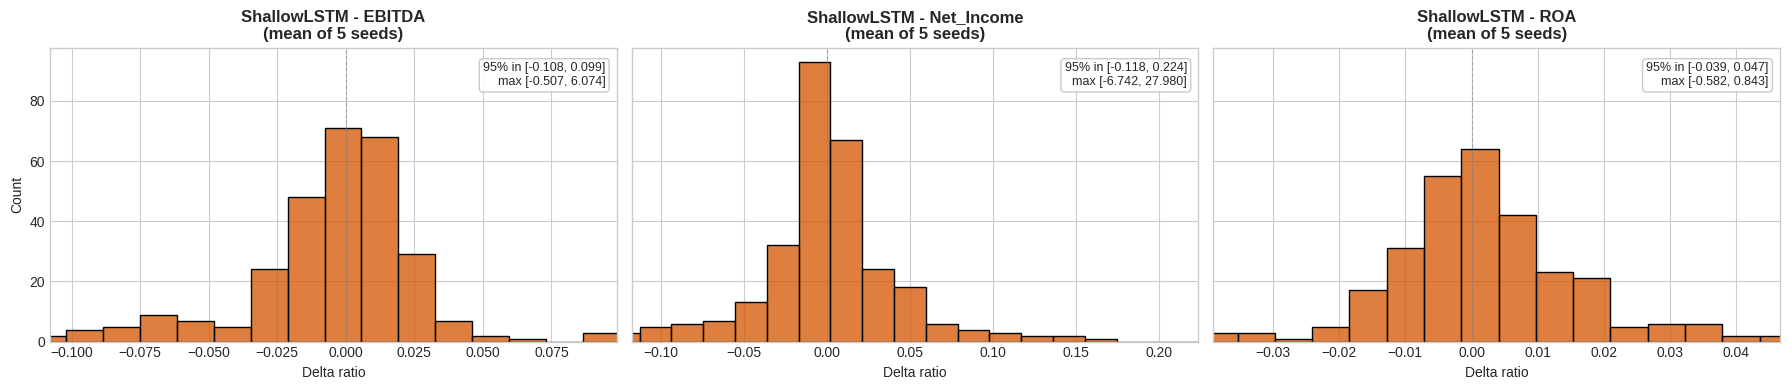

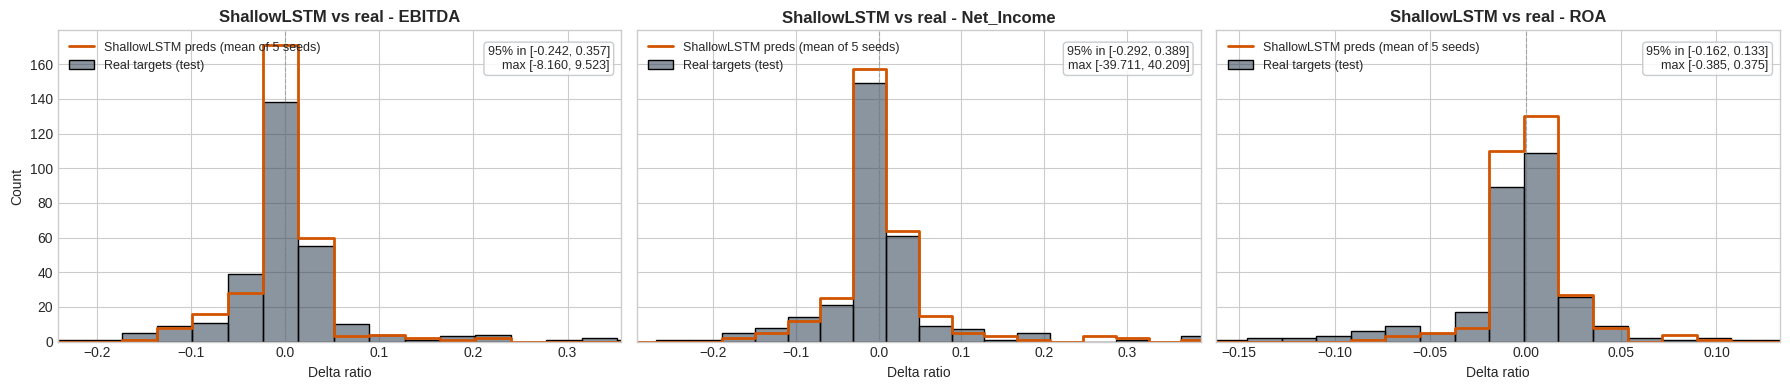

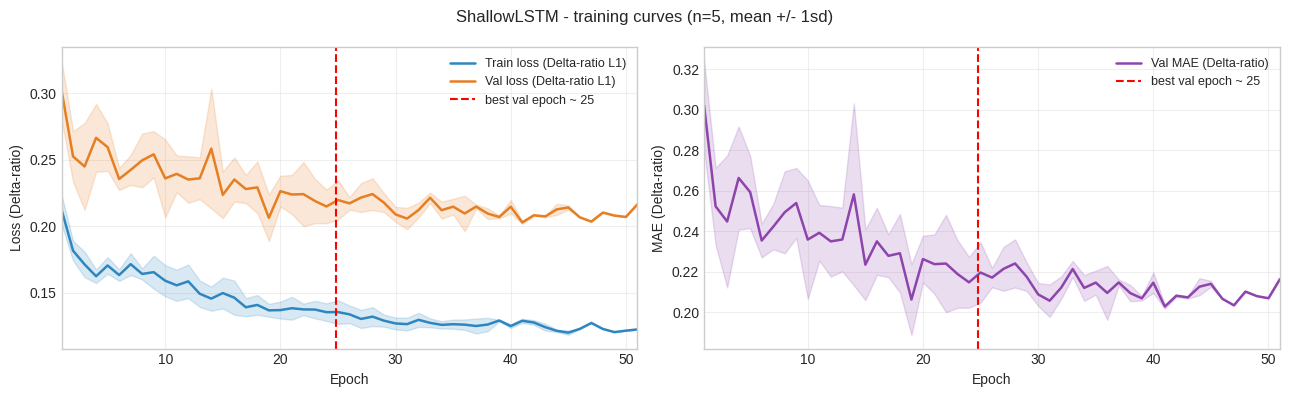

In [ ]:
params_A = study_A.best_trial.params
print(f"ShallowLSTM final params: {params_A}")
def make_A(params):
    return make_shallow_mtl(train_data, val_data, params, selected_indices)
_t0 = _time.time()
results_A, test_res_A, preds_A, hist_A, raw_A = run_n_seeded_final(make_A, params_A, fwd_mtl, n_seeds=N_FINAL_SEEDS)
print(f"\nShallowLSTM final test (n={N_FINAL_SEEDS} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_A[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_A, "ShallowLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_A, "ShallowLSTM")
plot_predictions_vs_targets(preds_A, "ShallowLSTM")
plot_training_curves(hist_A, "ShallowLSTM")

StackedLSTM L=4 final params: {'hidden_size': 32, 'lr': 0.004720627112368398, 'batch_size': 32, 'weight_decay': 7.440091682715945e-05, 'dropout': 0.19676616504955433}

StackedLSTM L=4 final test (n=5 seeds):
  EBITDA      : 0.1258 ± 0.0021
  Net_Income  : 0.3301 ± 0.0033
  ROA         : 0.0519 ± 0.0061
  Overall     : 0.1693 ± 0.0032
  Raw-scale test MAE StackedLSTM L=4 (Delta-ratio -> raw):
    EBITDA     : nMAE 32.2% ± 2.0% | R² 0.392 ± 0.094
    Net_Income : nMAE 64.3% ± 4.6% | R² -0.208 ± 0.284
    ROA        : nMAE 90.2% ± 10.5% | R² -3.546 ± 1.799
Time: 5.4 min


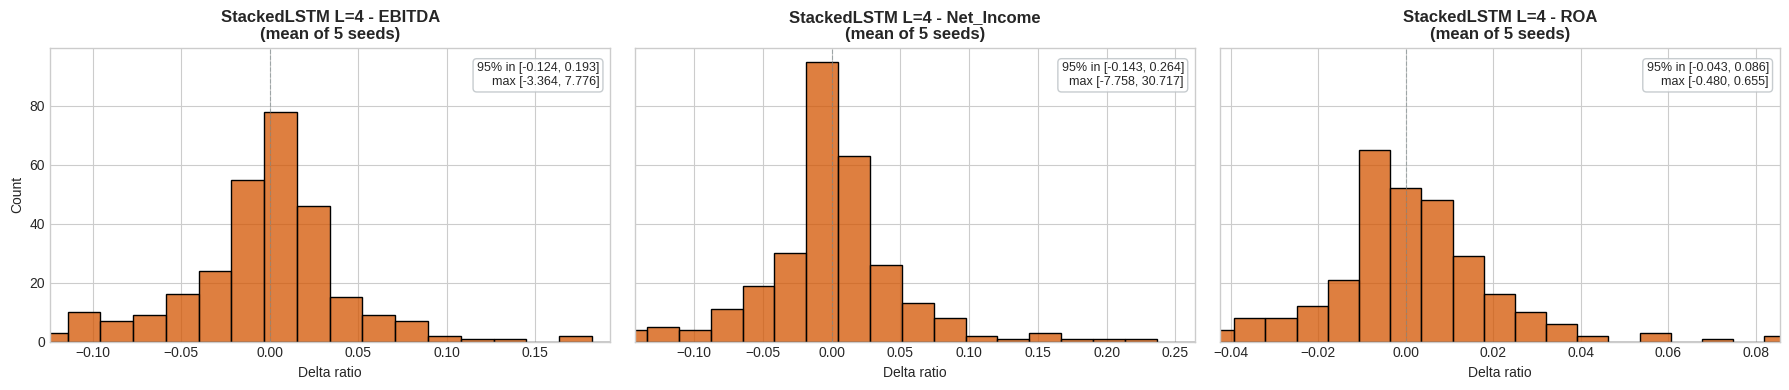

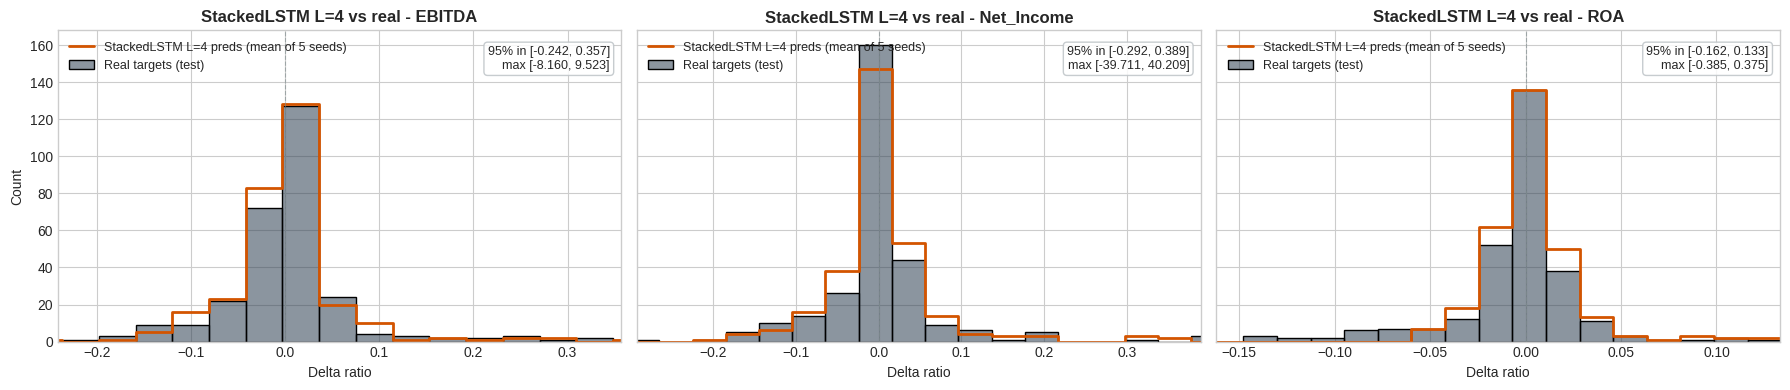

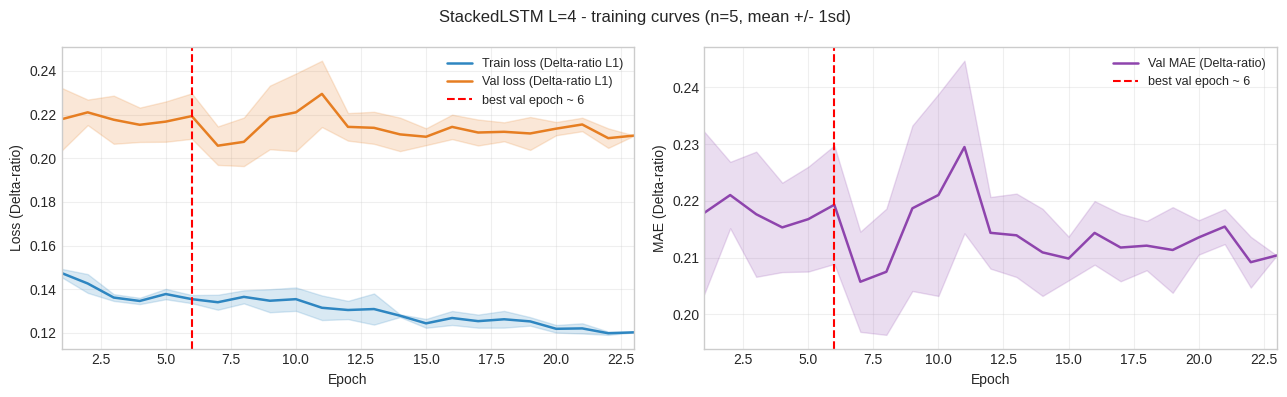

In [ ]:
params_B = study_B.best_trial.params
print(f"StackedLSTM L=4 final params: {params_B}")
def make_B(params):
    return make_stacked_mtl(train_data, val_data, params, selected_indices, num_layers=4)
_t0 = _time.time()
results_B, test_res_B, preds_B, hist_B, raw_B = run_n_seeded_final(make_B, params_B, fwd_mtl, n_seeds=N_FINAL_SEEDS)
print(f"\nStackedLSTM L=4 final test (n={N_FINAL_SEEDS} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_B[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_B, "StackedLSTM L=4 (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_B, "StackedLSTM L=4")
plot_predictions_vs_targets(preds_B, "StackedLSTM L=4")
plot_training_curves(hist_B, "StackedLSTM L=4")

In [ ]:
def make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params):
    """Model C loader builder: daily + monthly only.
    IT_GDP is folded into the monthly stream (forward-filled at monthly
    cadence); no separate quarterly MLP is used.
    """
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM final params: {'batch_size': 32, 'lr': 0.003426541759056412, 'weight_decay': 1.069527919185214e-05, 'dropout': 0.13400855244002063, 'n_layers_daily': 2, 'n_layers_monthly': 1}

MultiFreqLSTM final test (n=2 seeds):
  EBITDA      : 0.1248 ± 0.0025
  Net_Income  : 0.3285 ± 0.0006
  ROA         : 0.0408 ± 0.0031
  Overall     : 0.1647 ± 0.0017
  Raw-scale test MAE MultiFreqLSTM (Delta-ratio -> raw):
    EBITDA     : nMAE 36.7% ± 0.2% | R² 0.291 ± 0.026
    Net_Income : nMAE 67.0% ± 3.3% | R² -0.473 ± 0.170
    ROA        : nMAE 71.2% ± 5.3% | R² -0.906 ± 0.882
Time: 61.7 min


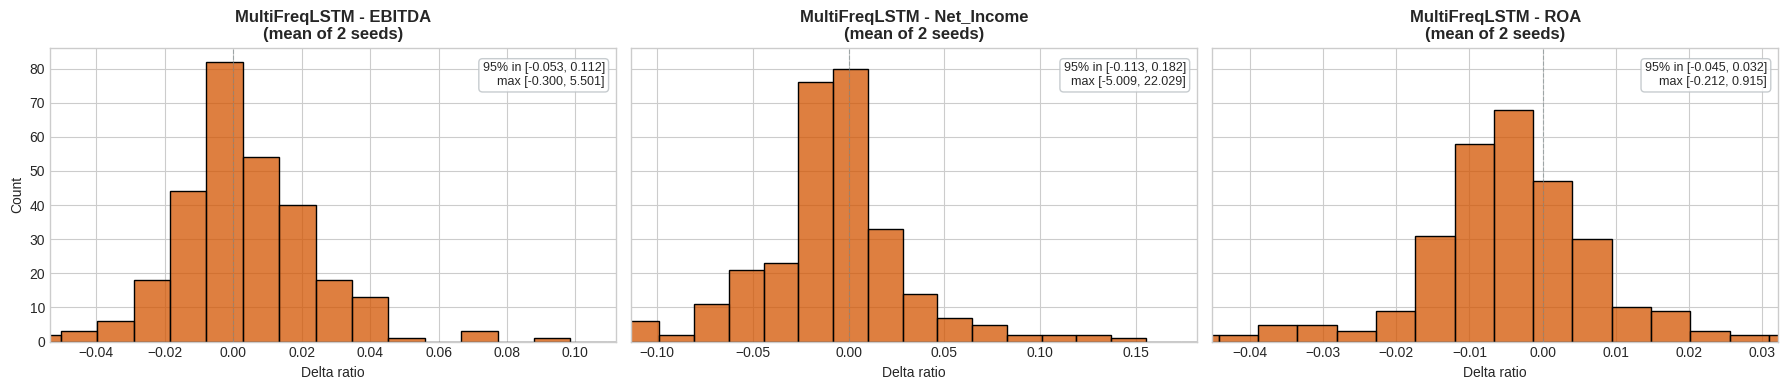

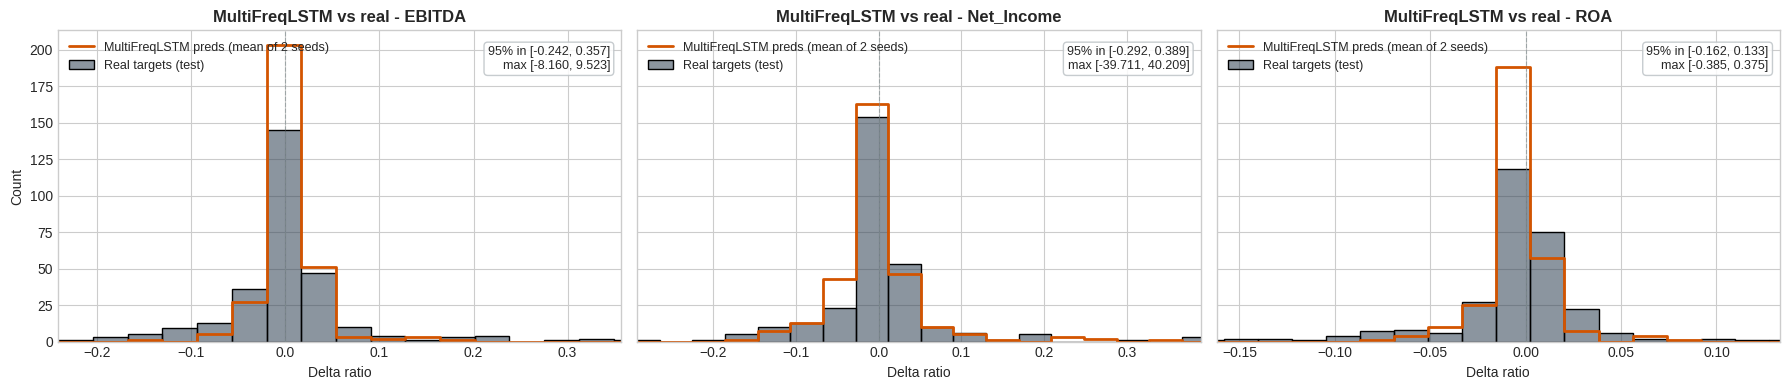

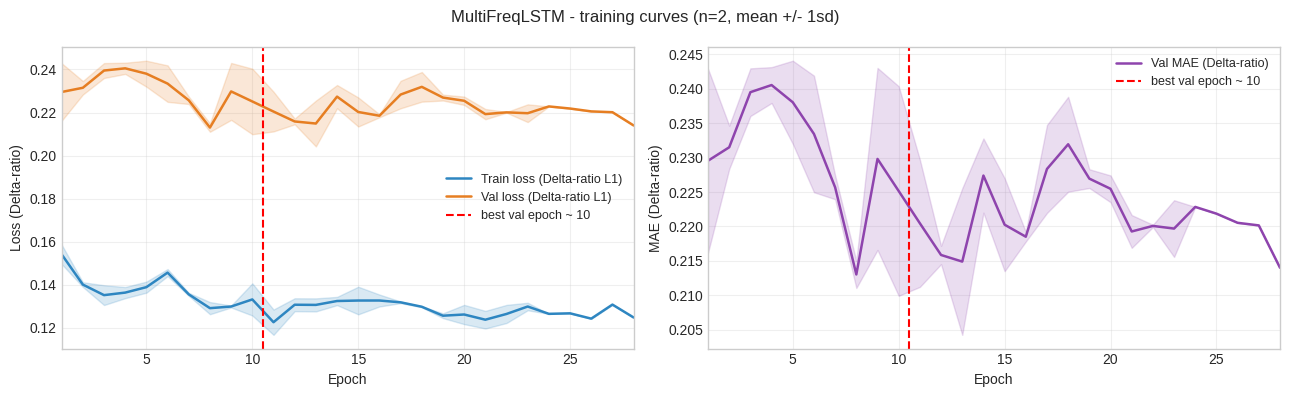

In [ ]:
def make_C(params):
    return make_multifreq_gdp_loaders_for_fold(train_data, val_data, params)

params_C = study_C.best_trial.params
print(f"MultiFreqLSTM final params: {params_C}")
N_FINAL_SEEDS_C = 2
_t0 = _time.time()
results_C, test_res_C, preds_C, hist_C, raw_C = run_n_seeded_final(make_C, params_C, fwd_mf, n_seeds=N_FINAL_SEEDS_C)
print(f"\nMultiFreqLSTM final test (n={N_FINAL_SEEDS_C} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_C[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_C, "MultiFreqLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_C, "MultiFreqLSTM")
plot_predictions_vs_targets(preds_C, "MultiFreqLSTM")
plot_training_curves(hist_C, "MultiFreqLSTM")


In [ ]:
def make_grouped_loaders_for_fold(tr_df, va_df, params):
    """Model D loader builder: K correlation-grouped daily streams.
    Grouping is recomputed from tr_df only (no leakage from val/test)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
    va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
    te_ds = GroupedDataset(te_mtl_s, groups, scaler, None, n_daily=252)
    bs = params['batch_size']
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader


GroupedLSTM final params: {'batch_size': 32, 'lr': 0.005031423353614856, 'weight_decay': 0.0009883273916572637, 'dropout': 0.26065240793146327, 'hidden_sizes': [64, 32, 32], 'n_layers': [2, 1, 1]}

GroupedLSTM final test (n=2 seeds):
  EBITDA      : 0.1228 ± 0.0002
  Net_Income  : 0.3276 ± 0.0006
  ROA         : 0.0361 ± 0.0021
  Overall     : 0.1622 ± 0.0006
  Raw-scale test MAE GroupedLSTM (Delta-ratio -> raw):
    EBITDA     : nMAE 35.2% ± 1.9% | R² 0.241 ± 0.071
    Net_Income : nMAE 69.8% ± 2.2% | R² -0.593 ± 0.157
    ROA        : nMAE 63.2% ± 3.7% | R² 0.285 ± 0.026
Time: 87.2 min


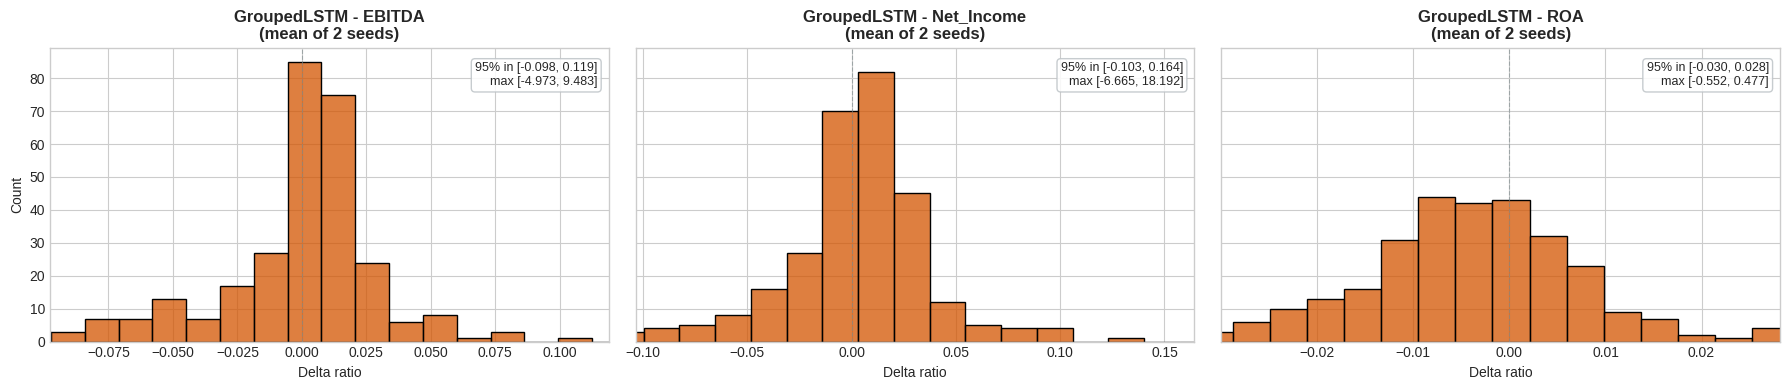

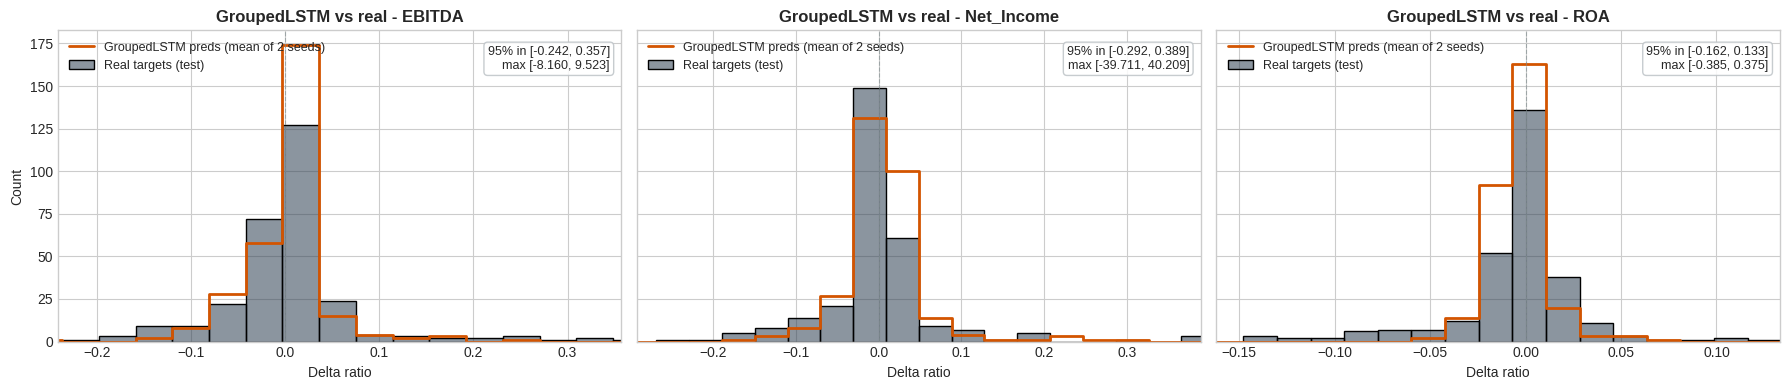

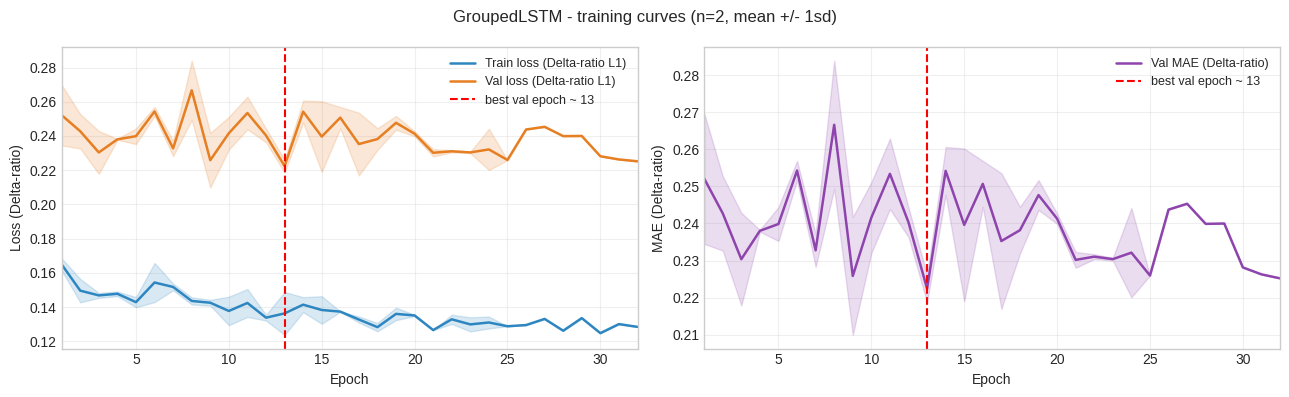

In [ ]:
def make_D(params):
    return make_grouped_loaders_for_fold(train_data, val_data, params)

params_D = study_D.best_trial.params
print(f"GroupedLSTM final params: {params_D}")
N_FINAL_SEEDS_D = 2
_t0 = _time.time()
results_D, test_res_D, preds_D, hist_D, raw_D = run_n_seeded_final(make_D, params_D, fwd_grouped, n_seeds=N_FINAL_SEEDS_D)
print(f"\nGroupedLSTM final test (n={N_FINAL_SEEDS_D} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_D[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_D, "GroupedLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_D, "GroupedLSTM")
plot_predictions_vs_targets(preds_D, "GroupedLSTM")
plot_training_curves(hist_D, "GroupedLSTM")


## Per-Fold Evaluation

In [ ]:
N_SEEDS_PER_FOLD = 3

def run_per_fold_final(make_model_fn, params, adapt,
                       n_seeds=N_SEEDS_PER_FOLD, collect_preds=True):
    """For each fold, train `n_seeds` models with the given params and evaluate
    on that fold's held-out year. `make_model_fn(params, tr_df, va_df)` builds
    loaders for the fold; `adapt` handles the batch layout.
    Returns per_fold[fold_idx] = {
        'val_year', 'seed_maes', 'preds_untrained', 'preds_trained',
        'targets', 'masks', 'histories',
    }"""
    per_fold = {}
    for fold_idx, (tr_df, va_df, val_year, fi) in enumerate(folds):
        seed_maes = []
        preds_u_dict = {}
        preds_t_dict = {}
        targets_arr = None
        masks_arr = None
        histories = {}
        raw_trained = {t: {"nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
        raw_untrained = {t: {"nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
        for s in range(n_seeds):
            np.random.seed(SEED + s); torch.manual_seed(SEED + s)
            if collect_preds:
                # Untrained baseline predictions
                model_u, _, _, te_loader_u = make_model_fn(params, tr_df, va_df)
                yp_u, _, _ = collect_predictions(model_u, te_loader_u, adapt)
                yp_u_aligned = collect_predictions_aligned(model_u, te_loader_u, adapt)
                _rm_u = raw_mae_delta_ratio(yp_u_aligned, test_meta)
                for _k, _v in _rm_u.items():
                    raw_untrained[_k]["nmae_pct"].append(_v["nmae_pct"])
                    raw_untrained[_k]["r2"].append(_v["r2"])
                del model_u
            # Train
            np.random.seed(SEED + s); torch.manual_seed(SEED + s)
            model, tr_loader, va_loader, te_loader = make_model_fn(params, tr_df, va_df)
            optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
            model, _, _, history = train_and_eval(
                model, tr_loader, va_loader, optimizer, adapt, collect_history=True)
            seed_maes.append(evaluate_loader(model, te_loader, adapt))
            yp_t_aligned = collect_predictions_aligned(model, te_loader, adapt)
            _rm_t = raw_mae_delta_ratio(yp_t_aligned, test_meta)
            for _k, _v in _rm_t.items():
                raw_trained[_k]["nmae_pct"].append(_v["nmae_pct"])
                raw_trained[_k]["r2"].append(_v["r2"])
            if collect_preds:
                yp_t, yt_chk, mask_chk = collect_predictions(model, te_loader, adapt)
                targets_arr = yt_chk
                masks_arr = mask_chk
                preds_u_dict[s] = yp_u
                preds_t_dict[s] = yp_t
            histories[s] = history
            del model
        per_fold[fold_idx] = {
            'val_year': int(val_year),
            'seed_maes': seed_maes,
            'preds_untrained': preds_u_dict,
            'preds_trained': preds_t_dict,
            'targets': targets_arr,
            'masks': masks_arr,
            'histories': histories,
            'raw_trained': raw_trained,
            'raw_untrained': raw_untrained,
        }
        maes_overall = [m['Overall'] for m in seed_maes]
        print(f"  Fold {fi} (val={val_year}): "
              f"Overall MAE = {np.mean(maes_overall):.4f} ± {np.std(maes_overall):.4f}")
        print_fold_raw(raw_trained, 'trained')
        if collect_preds:
            print_fold_raw(raw_untrained, 'untrained')
    print('  Cross-fold raw-scale (mean of seeds per fold, then across folds):')
    print_cross_fold_raw([per_fold[i]['raw_trained'] for i in sorted(per_fold)], 'trained')
    if collect_preds:
        print_cross_fold_raw([per_fold[i]['raw_untrained'] for i in sorted(per_fold)], 'untrained')
    return per_fold


In [ ]:
def make_A_for_fold(params, tr_df, va_df):
    return make_shallow_mtl(tr_df, va_df, params, selected_indices)

def make_B_for_fold(params, tr_df, va_df):
    return make_stacked_mtl(tr_df, va_df, params, selected_indices, num_layers=4)

ShallowLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.1680 ± 0.0011
    trained   : nMAE% EBITDA 30.7% | Net_Income 62.3% | ROA 73.8%
                R2   EBITDA 0.59 | Net_Income 0.07 | ROA -1.41
    untrained : nMAE% EBITDA 33.8% | Net_Income 68.5% | ROA 68.6%
                R2   EBITDA 0.35 | Net_Income -0.40 | ROA -0.50
  Fold 2 (val=2020): Overall MAE = 0.1776 ± 0.0105
    trained   : nMAE% EBITDA 37.1% | Net_Income 83.0% | ROA 108.4%
                R2   EBITDA 0.45 | Net_Income -0.76 | ROA -11.14
    untrained : nMAE% EBITDA 33.9% | Net_Income 68.8% | ROA 68.9%
                R2   EBITDA 0.35 | Net_Income -0.41 | ROA -0.54
  Fold 3 (val=2021): Overall MAE = 0.1822 ± 0.0196
    trained   : nMAE% EBITDA 30.5% | Net_Income 58.4% | ROA 88.2%
                R2   EBITDA 0.50 | Net_Income 0.09 | ROA -4.98
    untrained : nMAE% EBITDA 33.8% | Net_Income 69.3% | ROA 68.8%
                R2   EBITDA 0.35 | Net_Income -0.42 | ROA -0.57
  Fold 4 (val=2022): Overall MAE = 0.171

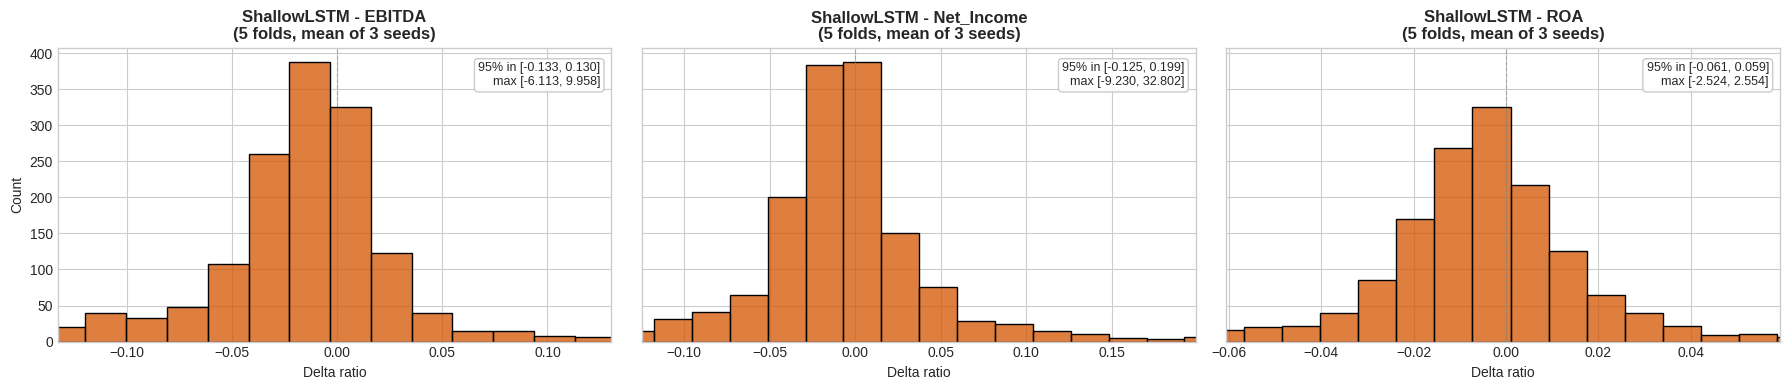

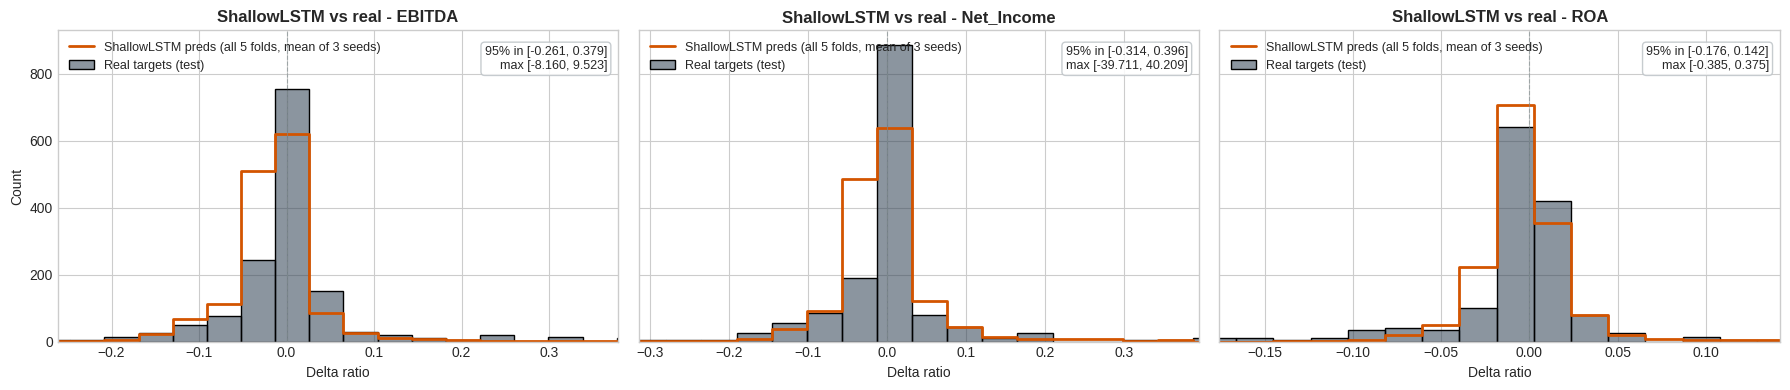

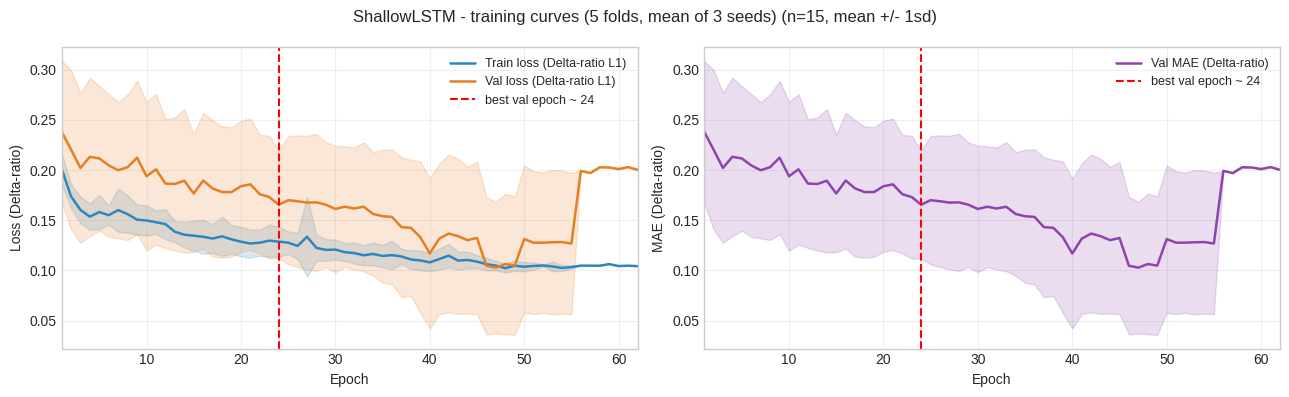

In [ ]:
print("ShallowLSTM per-fold test:")
_t0 = _time.time()
per_fold_A = run_per_fold_final(make_A_for_fold, params_A, fwd_mtl, n_seeds=3)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_A, "ShallowLSTM")
plot_predictions_vs_targets_agg(per_fold_A, "ShallowLSTM")
plot_training_curves_agg(per_fold_A, "ShallowLSTM")

StackedLSTM L=4 per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.1615 ± 0.0011
    trained   : nMAE% EBITDA 33.5% | Net_Income 64.2% | ROA 59.9%
                R2   EBITDA 0.35 | Net_Income -0.35 | ROA 0.16
    untrained : nMAE% EBITDA 34.5% | Net_Income 67.5% | ROA 64.0%
                R2   EBITDA 0.33 | Net_Income -0.40 | ROA -0.08
  Fold 2 (val=2020): Overall MAE = 0.1670 ± 0.0036
    trained   : nMAE% EBITDA 35.1% | Net_Income 71.5% | ROA 72.5%
                R2   EBITDA 0.28 | Net_Income -0.51 | ROA -0.88
    untrained : nMAE% EBITDA 34.5% | Net_Income 67.2% | ROA 64.1%
                R2   EBITDA 0.32 | Net_Income -0.39 | ROA -0.10
  Fold 3 (val=2021): Overall MAE = 0.1746 ± 0.0032
    trained   : nMAE% EBITDA 37.2% | Net_Income 66.3% | ROA 99.1%
                R2   EBITDA 0.28 | Net_Income -0.36 | ROA -6.23
    untrained : nMAE% EBITDA 34.4% | Net_Income 67.6% | ROA 64.2%
                R2   EBITDA 0.33 | Net_Income -0.41 | ROA -0.10
  Fold 4 (val=2022): Overall MAE = 0.

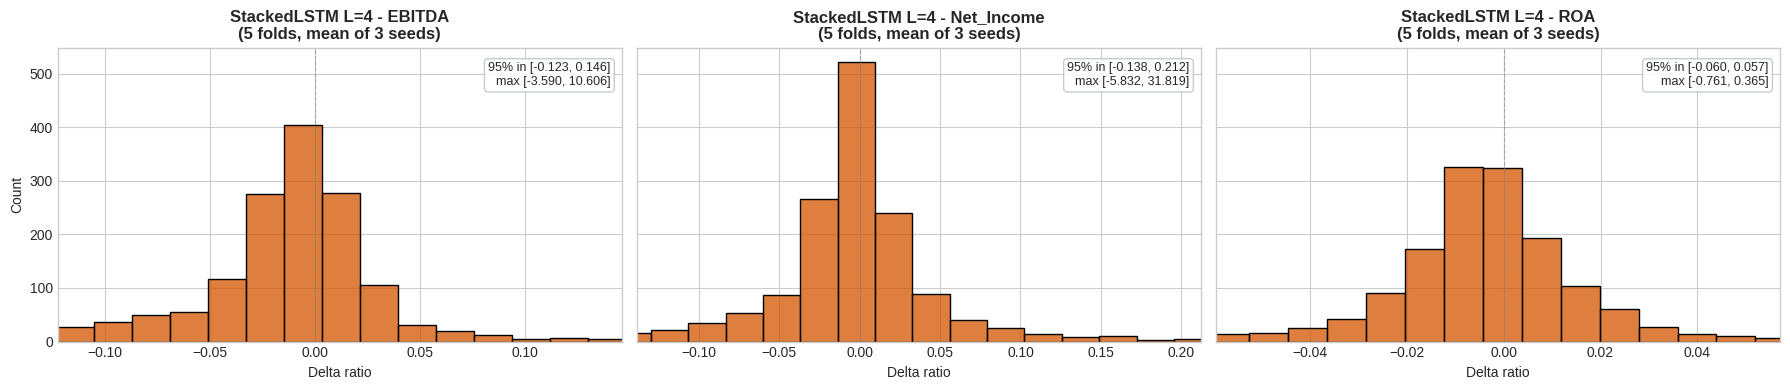

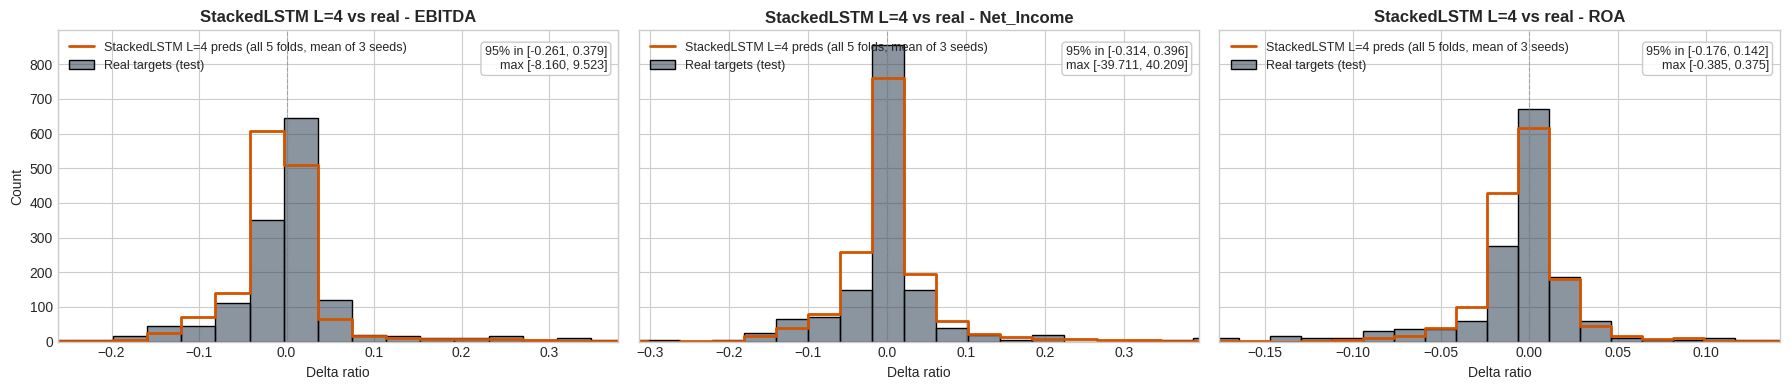

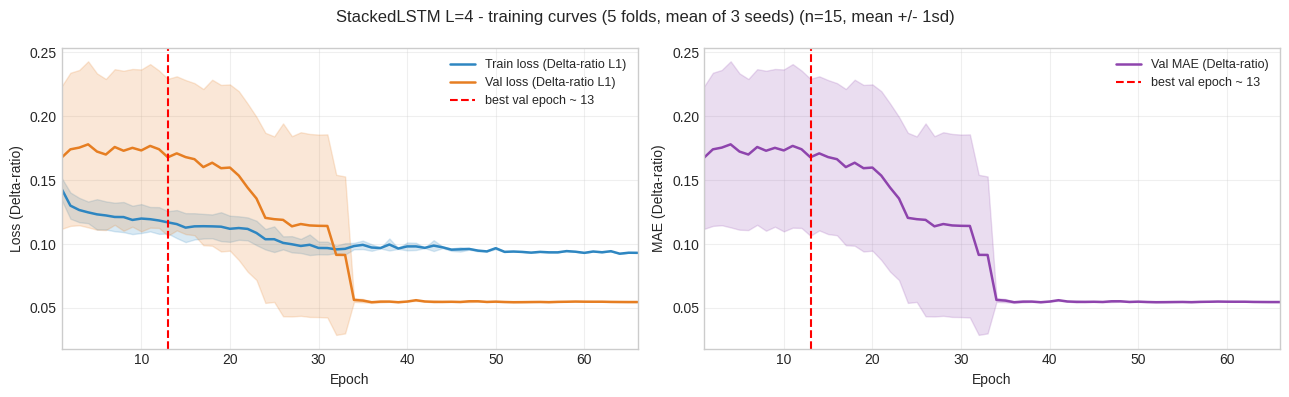

In [ ]:
print("StackedLSTM L=4 per-fold test:")
_t0 = _time.time()
per_fold_B = run_per_fold_final(make_B_for_fold, params_B, fwd_mtl, n_seeds=3)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_B, "StackedLSTM L=4")
plot_predictions_vs_targets_agg(per_fold_B, "StackedLSTM L=4")
plot_training_curves_agg(per_fold_B, "StackedLSTM L=4")

In [ ]:
def make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params):
    """Model C loader builder: daily + monthly only.
    IT_GDP is folded into the monthly stream (forward-filled at monthly
    cadence); no separate quarterly MLP is used.
    """
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.1638 ± 0.0000
    trained   : nMAE% EBITDA 33.6% | Net_Income 56.9% | ROA 67.6%
                R2   EBITDA 0.40 | Net_Income -0.03 | ROA -0.78
    untrained : nMAE% EBITDA 33.8% | Net_Income 67.9% | ROA 78.5%
                R2   EBITDA 0.35 | Net_Income -0.49 | ROA -2.83
  Fold 2 (val=2020): Overall MAE = 0.1835 ± 0.0000
    trained   : nMAE% EBITDA 39.7% | Net_Income 96.8% | ROA 106.6%
                R2   EBITDA 0.28 | Net_Income -0.32 | ROA -3.30
    untrained : nMAE% EBITDA 33.8% | Net_Income 68.2% | ROA 79.1%
                R2   EBITDA 0.35 | Net_Income -0.51 | ROA -3.00
  Fold 3 (val=2021): Overall MAE = 0.1658 ± 0.0000
    trained   : nMAE% EBITDA 31.3% | Net_Income 58.4% | ROA 72.4%
                R2   EBITDA 0.42 | Net_Income -0.10 | ROA -0.53
    untrained : nMAE% EBITDA 34.0% | Net_Income 67.9% | ROA 80.2%
                R2   EBITDA 0.34 | Net_Income -0.50 | ROA -3.22
  Fold 4 (val=2022): Overall MAE = 0.

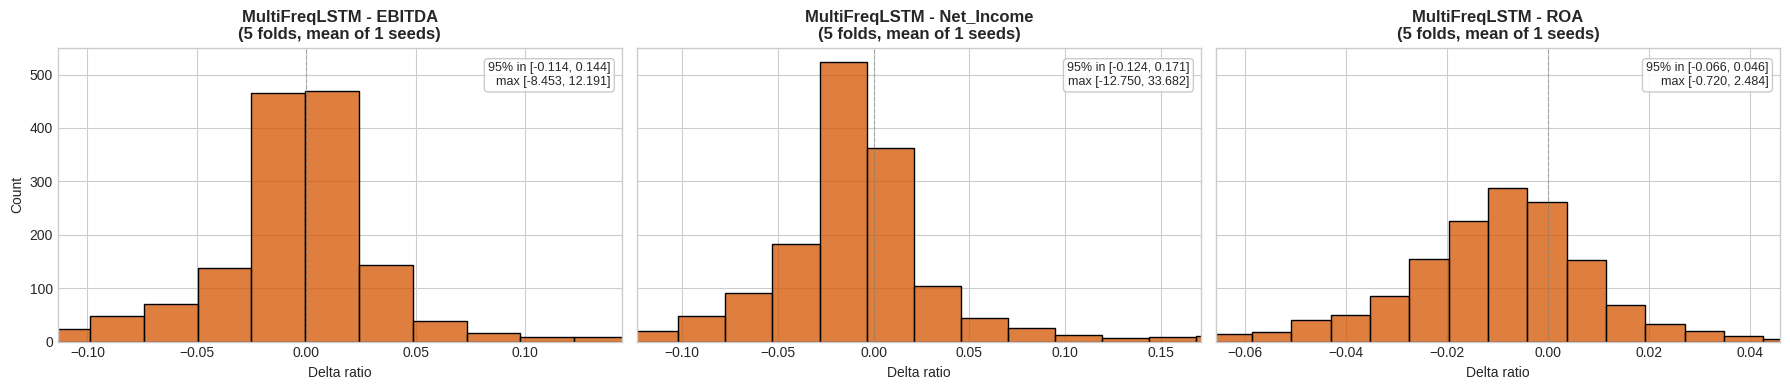

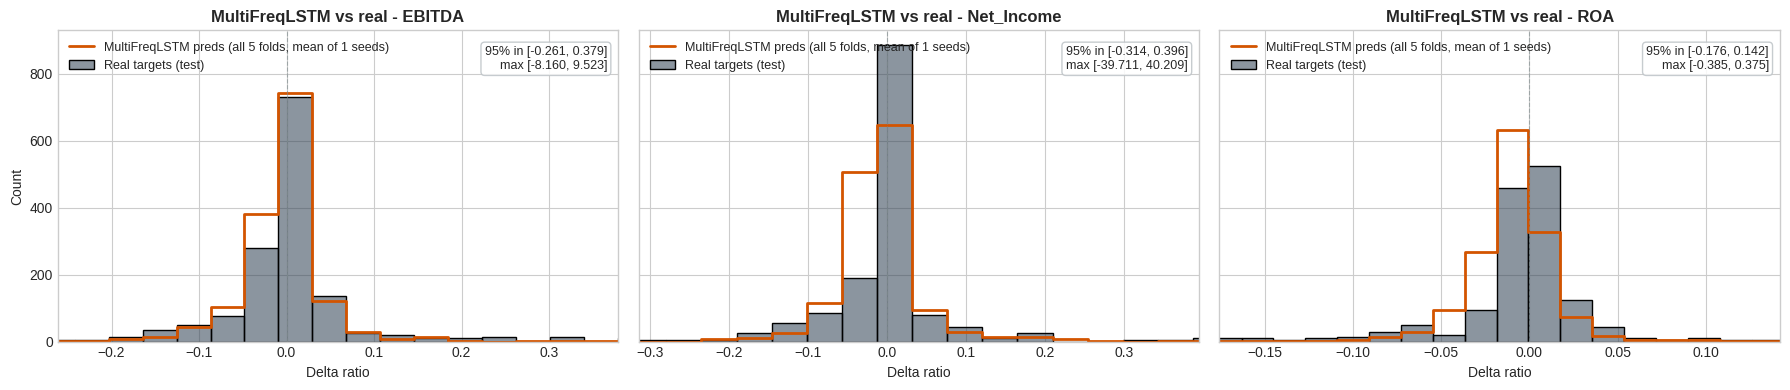

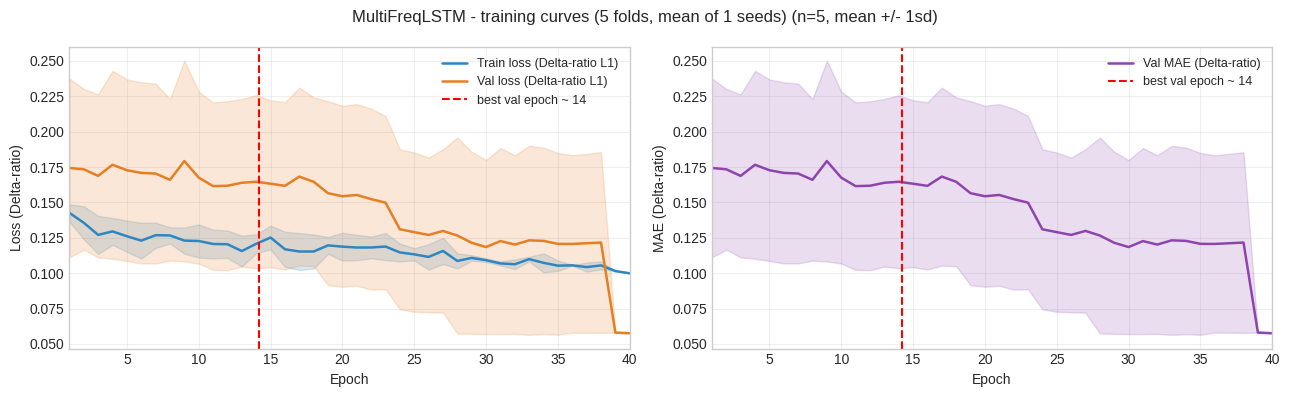

In [ ]:
def make_C_for_fold(params, tr_df, va_df):
    return make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params)

if not params_C:
    raise RuntimeError(
        "Model C Optuna results are empty. Run the Model C Optuna cell and fill"
        "_OPTUNA_RESULTS_C before running this cell."
    )
print("MultiFreqLSTM per-fold test:")
_t0 = _time.time()
per_fold_C = run_per_fold_final(make_C_for_fold, params_C, fwd_mf, n_seeds=1)  # 1 seed because takes longer
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_C, "MultiFreqLSTM")
plot_predictions_vs_targets_agg(per_fold_C, "MultiFreqLSTM")
plot_training_curves_agg(per_fold_C, "MultiFreqLSTM")


In [ ]:
def make_grouped_loaders_for_fold(tr_df, va_df, params):
    """Model D loader builder: K correlation-grouped daily streams.
    Grouping is recomputed from tr_df only (no leakage from val/test)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
    va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
    te_ds = GroupedDataset(te_mtl_s, groups, scaler, None, n_daily=252)
    bs = params['batch_size']
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, tr_loader, va_loader, te_loader


GroupedLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.1619 ± 0.0000
    trained   : nMAE% EBITDA 33.2% | Net_Income 64.2% | ROA 65.8%
                R2   EBITDA 0.32 | Net_Income -0.33 | ROA -0.44
    untrained : nMAE% EBITDA 33.2% | Net_Income 64.9% | ROA 62.7%
                R2   EBITDA 0.36 | Net_Income -0.33 | ROA 0.21
  Fold 2 (val=2020): Overall MAE = 0.1690 ± 0.0000
    trained   : nMAE% EBITDA 31.5% | Net_Income 70.9% | ROA 83.3%
                R2   EBITDA 0.53 | Net_Income -0.43 | ROA -1.92
    untrained : nMAE% EBITDA 33.2% | Net_Income 65.1% | ROA 62.6%
                R2   EBITDA 0.36 | Net_Income -0.35 | ROA 0.21
  Fold 3 (val=2021): Overall MAE = 0.1651 ± 0.0000
    trained   : nMAE% EBITDA 28.2% | Net_Income 59.1% | ROA 66.4%
                R2   EBITDA 0.59 | Net_Income -0.06 | ROA 0.00
    untrained : nMAE% EBITDA 33.4% | Net_Income 65.0% | ROA 62.5%
                R2   EBITDA 0.36 | Net_Income -0.36 | ROA 0.21
  Fold 4 (val=2022): Overall MAE = 0.1608 ± 

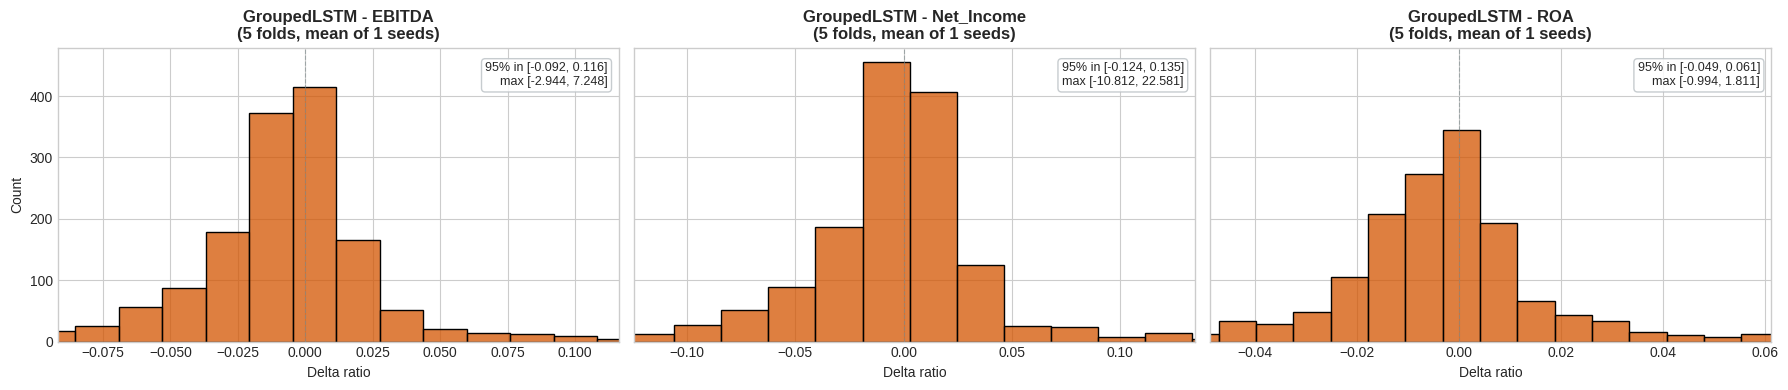

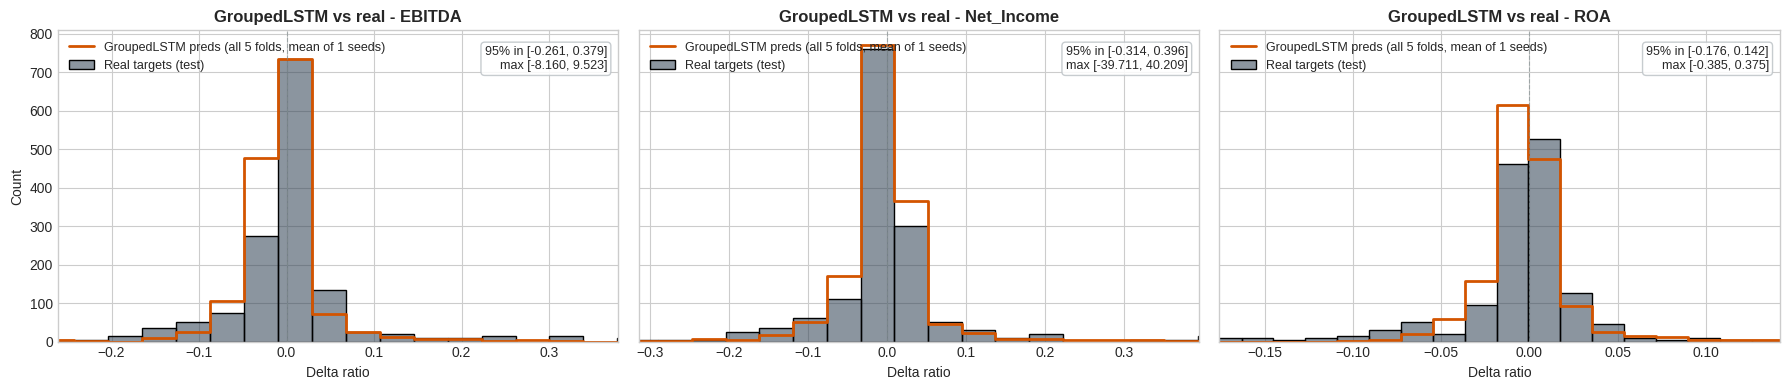

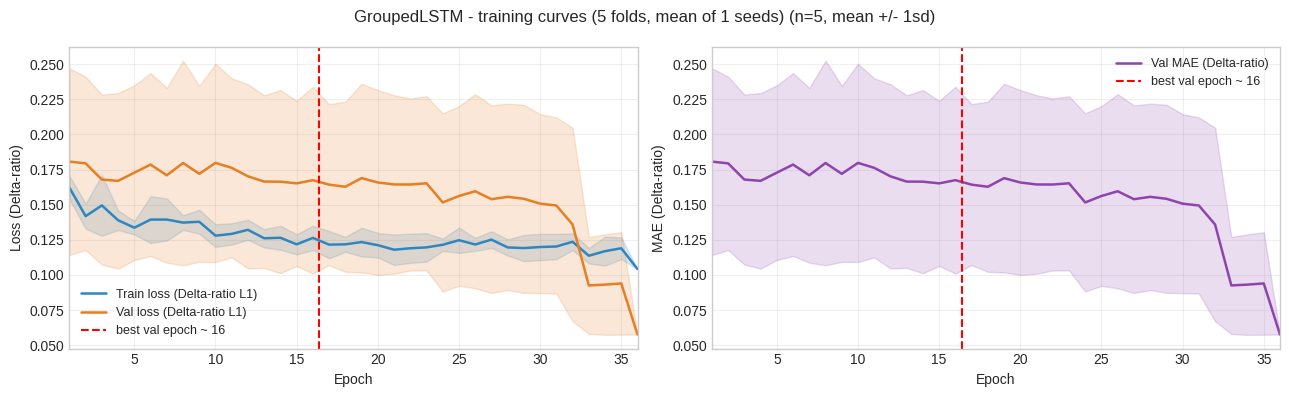

In [20]:
def make_D_for_fold(params, tr_df, va_df):
    return make_grouped_loaders_for_fold(tr_df, va_df, params)

if not params_D:
    raise RuntimeError(
        "Model D Optuna results are empty. Run the Model D Optuna cell and fill"
        "_OPTUNA_RESULTS_D before running this cell."
    )
print("GroupedLSTM per-fold test:")
_t0 = _time.time()
per_fold_D = run_per_fold_final(make_D_for_fold, params_D, fwd_grouped, n_seeds=1)  # 1 seed because takes longer
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_D, "GroupedLSTM")
plot_predictions_vs_targets_agg(per_fold_D, "GroupedLSTM")
plot_training_curves_agg(per_fold_D, "GroupedLSTM")


## Final Comparison Table

In [2]:
SINGLE_SPLIT = {
    "ShallowLSTM": {
        "n_seeds": 5,
        "EBITDA":     (0.1245, 0.0025),
        "Net_Income": (0.3277, 0.0011),
        "ROA":        (0.0436, 0.0054),
        "Overall":    (0.1652, 0.0019),
    },
    "StackedLSTM L=4": {
        "n_seeds": 5,
        "EBITDA":     (0.1258, 0.0021),
        "Net_Income": (0.3301, 0.0033),
        "ROA":        (0.0519, 0.0061),
        "Overall":    (0.1693, 0.0032),
    },
    "MultiFreqLSTM": {
        "n_seeds": 2,
        "EBITDA":     (0.1248, 0.0025),
        "Net_Income": (0.3285, 0.0006),
        "ROA":        (0.0408, 0.0031),
        "Overall":    (0.1647, 0.0017),
    },
    "GroupedLSTM": {
        "n_seeds": 2,
        "EBITDA":     (0.1228, 0.0002),
        "Net_Income": (0.3276, 0.0006),
        "ROA":        (0.0361, 0.0021),
        "Overall":    (0.1622, 0.0006),
    },
}

PER_FOLD = {
    "ShallowLSTM":      {2019: 0.1680, 2020: 0.1776, 2021: 0.1822, 2022: 0.1714, 2023: 0.1666},
    "StackedLSTM L=4":  {2019: 0.1615, 2020: 0.1670, 2021: 0.1746, 2022: 0.1653, 2023: 0.1688},
    "MultiFreqLSTM":    {2019: 0.1638, 2020: 0.1835, 2021: 0.1658, 2022: 0.1615, 2023: 0.1664},
    "GroupedLSTM":      {2019: 0.1619, 2020: 0.1690, 2021: 0.1651, 2022: 0.1608, 2023: 0.1616},
}

OPTUNA_VAL = {
    "ShallowLSTM":     0.18284179270267487,
    "StackedLSTM L=4": 0.18459033966064453,
    "MultiFreqLSTM":   0.21362240612506866,
    "GroupedLSTM":     0.19444449245929718,
}

BEST_PARAMS = {
    "ShallowLSTM": {
        'hidden_size': 128,
        'lr': 0.009258075025171411,
        'batch_size': 16,
        'weight_decay': 0.00012878865067519215,
        'dropout': 0.06837538688873493,
    },
    "StackedLSTM L=4": {
        'hidden_size': 32,
        'lr': 0.004720627112368398,
        'batch_size': 32,
        'weight_decay': 7.440091682715945e-05,
        'dropout': 0.19676616504955433,
    },
    "MultiFreqLSTM": {
        'batch_size': 32,
        'lr': 0.003426541759056412,
        'weight_decay': 1.069527919185214e-05,
        'dropout': 0.13400855244002063,
        'n_layers_daily': 2,
        'n_layers_monthly': 1,
    },
    "GroupedLSTM": {
        'batch_size': 32,
        'lr': 0.005031423353614856,
        'weight_decay': 0.0009883273916572637,
        'dropout': 0.26065240793146327,
        'hidden_sizes': [64, 32, 32],
        'n_layers': [2, 1, 1],
    },
}

def pf_summary(pf):
    """Mean +/- std of per-fold means (std across the 5 fold means, population)."""
    means = list(pf.values())
    return f"{np.mean(means):.4f} \u00b1 {np.std(means):.4f}"

pf_str = {m: pf_summary(PER_FOLD[m]) for m in PER_FOLD}

print("Per-fold test MAE (Overall), per validation year:")
for m, pf in PER_FOLD.items():
    years = sorted(pf.keys())
    print(f"  {m:28s}: " + ", ".join(f"{y}: {pf[y]:.4f}" for y in years))
print()
print("Single-split test MAE (Overall):")
for m, r in SINGLE_SPLIT.items():
    print(f"  {m:28s} (n={r['n_seeds']} seeds): {r['Overall'][0]:.4f} \u00b1 {r['Overall'][1]:.4f}")

RAW_SCALE_SPLIT = {
    "ShallowLSTM": {
        "EBITDA":     {"nmae_pct": (32.1, 2.7), "r2": (0.457, 0.054)},
        "Net_Income": {"nmae_pct": (64.6, 7.8), "r2": (-0.302, 0.381)},
        "ROA":        {"nmae_pct": (75.9, 9.3), "r2": (-1.202, 0.954)},
    },
    "StackedLSTM L=4": {
        "EBITDA":     {"nmae_pct": (32.2, 2.0), "r2": (0.392, 0.094)},
        "Net_Income": {"nmae_pct": (64.3, 4.6), "r2": (-0.208, 0.284)},
        "ROA":        {"nmae_pct": (90.2, 10.5), "r2": (-3.546, 1.799)},
    },
    "MultiFreqLSTM": {
        "EBITDA":     {"nmae_pct": (36.7, 0.2), "r2": (0.291, 0.026)},
        "Net_Income": {"nmae_pct": (67.0, 3.3), "r2": (-0.473, 0.170)},
        "ROA":        {"nmae_pct": (71.2, 5.3), "r2": (-0.906, 0.882)},
    },
    "GroupedLSTM": {
        "EBITDA":     {"nmae_pct": (35.2, 1.9), "r2": (0.241, 0.071)},
        "Net_Income": {"nmae_pct": (69.8, 2.2), "r2": (-0.593, 0.157)},
        "ROA":        {"nmae_pct": (63.2, 3.7), "r2": (0.285, 0.026)},
    },
}
# NOTE: fill the (mean, std) tuples above from the "Raw-scale test MAE" lines printed by
# the final eval cells (nMAE% and R2, per target).

PER_FOLD_RAW_SCALE = {
    "ShallowLSTM":     {"nmae_pct": (63.1, 7.4), "r2": (-1.41, 1.28)},
    "StackedLSTM L=4": {"nmae_pct": (59.5, 5.0), "r2": (-0.72, 0.83)},
    "MultiFreqLSTM":   {"nmae_pct": (59.8, 10.9), "r2": (-0.35, 0.46)},
    "GroupedLSTM":     {"nmae_pct": (54.8, 3.9), "r2": (-0.10, 0.28)},
}
# NOTE: fill the (mean, std) tuples above from the "avg nMAE%/R2" lines of the cross-fold
# raw-scale summary printed by the per-fold eval cells.

Per-fold test MAE (Overall), per validation year:
  ShallowLSTM                 : 2019: 0.1680, 2020: 0.1776, 2021: 0.1822, 2022: 0.1714, 2023: 0.1666
  StackedLSTM L=4             : 2019: 0.1615, 2020: 0.1670, 2021: 0.1746, 2022: 0.1653, 2023: 0.1688
  MultiFreqLSTM               : 2019: 0.1638, 2020: 0.1835, 2021: 0.1658, 2022: 0.1615, 2023: 0.1664
  GroupedLSTM                 : 2019: 0.1619, 2020: 0.1690, 2021: 0.1651, 2022: 0.1608, 2023: 0.1616

Single-split test MAE (Overall):
  ShallowLSTM                  (n=5 seeds): 0.1652 ± 0.0019
  StackedLSTM L=4              (n=5 seeds): 0.1693 ± 0.0032
  MultiFreqLSTM                (n=2 seeds): 0.1647 ± 0.0017
  GroupedLSTM                  (n=2 seeds): 0.1622 ± 0.0006


In [3]:
summary = pd.DataFrame([
    {
        "Model": m,
        "Best Optuna val MAE": OPTUNA_VAL[m],
        "Test MAE (EBITDA margin)": f"{SINGLE_SPLIT[m]['EBITDA'][0]:.4f} ± {SINGLE_SPLIT[m]['EBITDA'][1]:.4f}",
        "Test MAE (net margin)": f"{SINGLE_SPLIT[m]['Net_Income'][0]:.4f} ± {SINGLE_SPLIT[m]['Net_Income'][1]:.4f}",
        "Test MAE (ROA)": f"{SINGLE_SPLIT[m]['ROA'][0]:.4f} ± {SINGLE_SPLIT[m]['ROA'][1]:.4f}",
        "Test MAE (Overall)": f"{SINGLE_SPLIT[m]['Overall'][0]:.4f} ± {SINGLE_SPLIT[m]['Overall'][1]:.4f}",
        "nMAE EBITDA (%)": f"{RAW_SCALE_SPLIT[m]['EBITDA']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['EBITDA']['nmae_pct'][1]:.1f}%",
        "nMAE Net_Income (%)": f"{RAW_SCALE_SPLIT[m]['Net_Income']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['Net_Income']['nmae_pct'][1]:.1f}%",
        "nMAE ROA (%)": f"{RAW_SCALE_SPLIT[m]['ROA']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['ROA']['nmae_pct'][1]:.1f}%",
        "R² EBITDA": f"{RAW_SCALE_SPLIT[m]['EBITDA']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['EBITDA']['r2'][1]:.3f}",
        "R² Net_Income": f"{RAW_SCALE_SPLIT[m]['Net_Income']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['Net_Income']['r2'][1]:.3f}",
        "R² ROA": f"{RAW_SCALE_SPLIT[m]['ROA']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['ROA']['r2'][1]:.3f}",
        "Per-fold test MAE": pf_str[m],
        "Per-fold nMAE (avg %)": f"{PER_FOLD_RAW_SCALE[m]['nmae_pct'][0]:.1f}% ± {PER_FOLD_RAW_SCALE[m]['nmae_pct'][1]:.1f}%",
        "Per-fold R2 (avg)": f"{PER_FOLD_RAW_SCALE[m]['r2'][0]:.2f} ± {PER_FOLD_RAW_SCALE[m]['r2'][1]:.2f}",
        "Best params": str(BEST_PARAMS[m]),
    }
    for m in ["ShallowLSTM", "StackedLSTM L=4", "MultiFreqLSTM", "GroupedLSTM"]
])
display(summary)

# Best model by single-split headline number
best_idx = summary["Test MAE (Overall)"].apply(lambda s: float(s.split(' ± ')[0])).idxmin()
print(f"\nBest model by single-split test Overall MAE: {summary.loc[best_idx, 'Model']}")
print(f"  Test MAE (Overall): {summary.loc[best_idx, 'Test MAE (Overall)']}")
print(f"  Per-fold test MAE:   {summary.loc[best_idx, 'Per-fold test MAE']}")

# Best model by per-fold test MAE
best_pf_idx = summary["Per-fold test MAE"].apply(lambda s: float(s.split(' ± ')[0])).idxmin()
print(f"\nBest model by per-fold test MAE: {summary.loc[best_pf_idx, 'Model']}")
print(f"  Per-fold test MAE:   {summary.loc[best_pf_idx, 'Per-fold test MAE']}")

,Model,Best Optuna val MAE,Test MAE (EBITDA margin),Test MAE (net margin),Test MAE (ROA),Test MAE (Overall),nMAE EBITDA (%),nMAE Net_Income (%),nMAE ROA (%),R² EBITDA,R² Net_Income,R² ROA,Per-fold test MAE,Per-fold nMAE (avg %),Per-fold R2 (avg),Best params
0,ShallowLSTM,0.182842,0.1245 ± 0.0025,0.3277 ± 0.0011,0.0436 ± 0.0054,0.1652 ± 0.0019,32.1% ± 2.7%,64.6% ± 7.8%,75.9% ± 9.3%,0.457 ± 0.054,-0.302 ± 0.381,-1.202 ± 0.954,0.1732 ± 0.0059,63.1% ± 7.4%,-1.41 ± 1.28,"{'hidden_size': 128, 'lr': 0.00925807502517141..."
1,StackedLSTM L=4,0.184590,0.1258 ± 0.0021,0.3301 ± 0.0033,0.0519 ± 0.0061,0.1693 ± 0.0032,32.2% ± 2.0%,64.3% ± 4.6%,90.2% ± 10.5%,0.392 ± 0.094,-0.208 ± 0.284,-3.546 ± 1.799,0.1674 ± 0.0043,59.5% ± 5.0%,-0.72 ± 0.83,"{'hidden_size': 32, 'lr': 0.004720627112368398..."
2,MultiFreqLSTM,0.213622,0.1248 ± 0.0025,0.3285 ± 0.0006,0.0408 ± 0.0031,0.1647 ± 0.0017,36.7% ± 0.2%,67.0% ± 3.3%,71.2% ± 5.3%,0.291 ± 0.026,-0.473 ± 0.170,-0.906 ± 0.882,0.1682 ± 0.0078,59.8% ± 10.9%,-0.35 ± 0.46,"{'batch_size': 32, 'lr': 0.003426541759056412,..."
3,GroupedLSTM,0.194444,0.1228 ± 0.0002,0.3276 ± 0.0006,0.0361 ± 0.0021,0.1622 ± 0.0006,35.2% ± 1.9%,69.8% ± 2.2%,63.2% ± 3.7%,0.241 ± 0.071,-0.593 ± 0.157,0.285 ± 0.026,0.1637 ± 0.0030,54.8% ± 3.9%,-0.10 ± 0.28,"{'batch_size': 32, 'lr': 0.005031423353614856,..."



Best model by single-split test Overall MAE: GroupedLSTM
  Test MAE (Overall): 0.1622 ± 0.0006
  Per-fold test MAE:   0.1637 ± 0.0030

Best model by per-fold test MAE: GroupedLSTM
  Per-fold test MAE:   0.1637 ± 0.0030


## 2025 as Validation

In [ ]:
TRAIN_MAX_YEAR_FV = 2022
VAL_YEAR_FV      = 2025
TEST_YEARS_FV    = [2023, 2024]

train_fv        = data_df[data_df["year"] <= TRAIN_MAX_YEAR_FV].copy().reset_index(drop=True)
val_fv          = data_df[data_df["year"] == VAL_YEAR_FV].copy().reset_index(drop=True)
test_2023_fv    = data_df[data_df["year"] == 2023].copy().reset_index(drop=True)
test_2024_fv    = data_df[data_df["year"] == 2024].copy().reset_index(drop=True)
test_combined_fv = pd.concat([test_2023_fv, test_2024_fv], ignore_index=True)

print(f"Train (year <= {TRAIN_MAX_YEAR_FV}): {len(train_fv)} samples")
print(f"Val   (year == {VAL_YEAR_FV}): {len(val_fv)} samples")
print(f"Test 2023: {len(test_2023_fv)} samples")
print(f"Test 2024: {len(test_2024_fv)} samples")
print(f"Test 2023+2024 (combined): {len(test_combined_fv)} samples")

mtl_train_fv_raw         = extract_mtl_df(train_fv)
mtl_val_fv_raw           = extract_mtl_df(val_fv)
mtl_test_2023_fv_raw     = extract_mtl_df(test_2023_fv)
mtl_test_2024_fv_raw     = extract_mtl_df(test_2024_fv)
mtl_test_combined_fv_raw = extract_mtl_df(test_combined_fv)

stat_sc_fv = fit_static_scaler(mtl_train_fv_raw, NEW_STATIC_SLICE)
mtl_train_fv         = apply_static_scaler(mtl_train_fv_raw,         stat_sc_fv, NEW_STATIC_SLICE)
mtl_val_fv_s         = apply_static_scaler(mtl_val_fv_raw,           stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_2023_fv     = apply_static_scaler(mtl_test_2023_fv_raw,     stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_2024_fv     = apply_static_scaler(mtl_test_2024_fv_raw,     stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_combined_fv = apply_static_scaler(mtl_test_combined_fv_raw, stat_sc_fv, NEW_STATIC_SLICE)


In [ ]:
def build_loaders_fv(params, num_layers: int):
    """Build train/val/test23/test24/test_combined loaders + StackedLSTM for the FV setup.
    Scalers fit on the FV-train fold only (no leakage from val=2025 or test 2023/2024).
    """
    temp_sc = make_robust_scaler(mtl_train_fv_raw, selected_indices)
    train_ds  = YoYDatasetMTL(mtl_train_fv,         temp_sc, selected_indices)
    val_ds    = YoYDatasetMTL(mtl_val_fv_s,         temp_sc, selected_indices)
    t23_ds    = YoYDatasetMTL(mtl_test_2023_fv,     temp_sc, selected_indices)
    t24_ds    = YoYDatasetMTL(mtl_test_2024_fv,     temp_sc, selected_indices)
    tc_ds     = YoYDatasetMTL(mtl_test_combined_fv, temp_sc, selected_indices)

    bs = params["batch_size"]
    train_loader         = DataLoader(train_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader           = DataLoader(val_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test23_loader        = DataLoader(t23_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test24_loader        = DataLoader(t24_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test_combined_loader = DataLoader(tc_ds,    batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)

    model = StackedLSTM(
        len(selected_indices), params["hidden_size"],
        num_layers=num_layers, num_targets=len(PREDICTION_TARGETS),
        dropout=params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP,
    ).to(DEVICE)
    init_lstm_submodule(model)
    return model, train_loader, val_loader, test23_loader, test24_loader, test_combined_loader


def eval_mae_per_target(model, loader):
    """Per-target MAE in Delta-ratio space."""
    return evaluate_loader(model, loader, fwd_mtl)


In [ ]:
FV_DEPTHS = [1, 2, 3, 4]
N_SEEDS_FV = 5

if "study_B" not in globals():
    raise RuntimeError(
        "study_B is not defined. Re-run the StackedLSTM Optuna cell (cell 24) "
        "so params_B reflects the corrected label transform + weight init."
    )
params_B_fv = dict(study_B.best_trial.params)
print(f"Using study_B best params (fixed across depths): {params_B_fv}")

fv_depth_results = []
fv_depth_best_epochs = {}
fv_histories = {}
fv_preds = {}

for nl in FV_DEPTHS:
    for seed_offset in range(N_SEEDS_FV):
        seed = SEED + seed_offset
        np.random.seed(seed)
        torch.manual_seed(seed)

        model, tr_loader, va_loader, t23_loader, t24_loader, tc_loader = \
            build_loaders_fv(params_B_fv, num_layers=nl)
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=params_B_fv["lr"],
            weight_decay=params_B_fv["weight_decay"],
        )

        # Use this notebook's training loop: L1, ReduceLROnPlateau, early stopping,
        # grad_clip=1.0, MAX_EPOCHS=100. Returns best_val_mae (real-space), best_epoch,
        # and (collect_history=True) the per-epoch history dict.
        model, best_val_mae, best_epoch, history = train_and_eval(
            model, tr_loader, va_loader, optimizer, fwd_mtl,
            collect_history=True
        )
        fv_histories.setdefault(nl, {})[seed] = history

        val_mae            = eval_mae_per_target(model, va_loader)
        test23_mae         = eval_mae_per_target(model, t23_loader)
        test24_mae         = eval_mae_per_target(model, t24_loader)
        test_combined_mae  = eval_mae_per_target(model, tc_loader)

        # Collect test predictions (2023+2024) for distribution plots.
        preds, targets, mask = collect_predictions(model, tc_loader, fwd_mtl)
        fv_preds.setdefault(nl, {})[seed] = (preds, targets, mask)

        for tgt in PREDICTION_TARGETS + ["Overall"]:
            fv_depth_results.append({
                "num_layers": nl, "seed": seed, "target": tgt,
                "val_2025_mae":      val_mae.get(tgt),
                "test_2023_mae":     test23_mae.get(tgt),
                "test_2024_mae":     test24_mae.get(tgt),
                "test_combined_mae": test_combined_mae.get(tgt),
                "best_val_mae":      best_val_mae,
                "best_epoch":        best_epoch,
            })
        fv_depth_best_epochs[(nl, seed)] = best_epoch
        print(f"[L={nl} seed={seed_offset}] val_2025={val_mae['Overall']:.4f} "
              f"test_2023={test23_mae['Overall']:.4f} test_2024={test24_mae['Overall']:.4f} "
              f"test_combined={test_combined_mae['Overall']:.4f} "
              f"best_val_mae={best_val_mae:.4f} @ ep {best_epoch}")

df_fv_runs = pd.DataFrame(fv_depth_results)
print(f"\n=== Depth sweep ({FV_DEPTHS} layers) \u2014 Train <= 2022, Val = 2025, Test = 2023 & 2024 ===")
print(f"Total runs: {len(df_fv_runs) // 4} (={len(FV_DEPTHS)} depths x {N_SEEDS_FV} seeds)")


In [ ]:
def fv_agg_mean_std(grp):
    metrics = ["val_2025_mae", "test_2023_mae", "test_2024_mae",
               "test_combined_mae", "best_val_mae", "best_epoch"]
    out = [int(len(grp))]
    for m in metrics:
        out.append(float(grp[m].mean()))
        out.append(float(grp[m].std()))
    return out

result = df_fv_runs.groupby(["num_layers", "target"]).apply(fv_agg_mean_std)
df_fv_summary = pd.DataFrame(result.tolist(), index=result.index).reset_index()
df_fv_summary.columns = [
    "num_layers", "target", "n_seeds",
    "val_2025_mae_mean", "val_2025_mae_std",
    "test_2023_mae_mean", "test_2023_mae_std",
    "test_2024_mae_mean", "test_2024_mae_std",
    "test_combined_mae_mean", "test_combined_mae_std",
    "best_val_mae_mean", "best_val_mae_std",
    "best_epoch_mean", "best_epoch_std",
]
display(df_fv_summary.round(4))

val_by_depth       = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_layers")["val_2025_mae_mean"]
test23_by_depth    = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_layers")["test_2023_mae_mean"]
test24_by_depth    = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_layers")["test_2024_mae_mean"]
test_comb_by_depth = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_layers")["test_combined_mae_mean"]

print("\n=== Verdict (FV, depth only, params from study_B) ===")
for metric_name, series in [
    ("Selection (val_2025)", val_by_depth),
    ("Test MAE (2023)",       test23_by_depth),
    ("Test MAE (2024)",       test24_by_depth),
    ("Test MAE (2023+2024)",  test_comb_by_depth),
]:
    best_L = series.idxmin()
    print(f"  {metric_name:25s}: best L={best_L} ({series[best_L]:.4f})")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
xs = np.arange(len(FV_DEPTHS))
width = 0.6
for i, (col, title) in enumerate([
    ("val_2025_mae_mean",     "Val MAE (2025, future)"),
    ("test_2023_mae_mean",    "Test MAE (2023)"),
    ("test_2024_mae_mean",    "Test MAE (2024)"),
    ("test_combined_mae_mean","Test MAE (2023+2024)"),
]):
    means = [df_fv_summary[(df_fv_summary["num_layers"] == L) & (df_fv_summary["target"] == "Overall")][col].iloc[0] for L in FV_DEPTHS]
    stds  = [df_fv_summary[(df_fv_summary["num_layers"] == L) & (df_fv_summary["target"] == "Overall")][col.replace("mean","std")].iloc[0] for L in FV_DEPTHS]
    ax[i].bar(xs, means, width, yerr=stds, capsize=4, color="steelblue", edgecolor="black")
    ax[i].set_xticks(xs); ax[i].set_xticklabels([f"L={L}" for L in FV_DEPTHS])
    ax[i].set_title(title); ax[i].set_ylabel("MAE (real space)")
    ax[i].grid(True, alpha=0.3, axis="y")
fig.suptitle(f"FV depth sweep \u2014 Train <= 2022, Val = 2025, Test = 2023 & 2024  (\u03bc \u00b1 \u03c3, n={N_SEEDS_FV})")
plt.tight_layout()
plt.show()

print(f"\n=== Curves & distributions for best depth (by val_2025 Overall MAE) ===")
best_depth_fv = int(val_by_depth.idxmin())
best_depth_seeds = sorted(fv_histories[best_depth_fv])
print(f"Best depth: L={best_depth_fv} (val_2025 MAE = {val_by_depth[best_depth_fv]:.4f}), "
      f"{len(best_depth_seeds)} seeds: {best_depth_seeds}")

plot_training_curves(
    [fv_histories[best_depth_fv][s] for s in best_depth_seeds],
    f"StackedLSTM FV (val=2025) L={best_depth_fv}",
    tag="best depth by val_2025, 5 seeds",
)
plot_prediction_distributions(
    [fv_preds[best_depth_fv][s] for s in best_depth_seeds],
    f"StackedLSTM FV (val=2025) L={best_depth_fv}",
)
plot_predictions_vs_targets(
    [fv_preds[best_depth_fv][s] for s in best_depth_seeds],
    f"StackedLSTM FV (val=2025) L={best_depth_fv}",
)
